# Model Selection of Vertical Profile of the Atmosphere

Some imports

In [1]:
# imports
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
import gruanpy as gp
from ssm.statsmodels.local_trend import LocalLinearTrend

Read gdps and prepare an iterator providing them one at time.

In [2]:
base = os.path.abspath(os.path.join(os.getcwd(), ".."))
pkl_path = os.path.join(base, "pblh_unc", "pkls", "gdp_2024_HKO-RS-01_2024.pkl")

with open(pkl_path, "rb") as f:
    dataset = pickle.load(f)

print("Dataset Loaded")

def gdp_iterator(dataset):
    for pid, gdp in dataset.items():
        yield pid, gdp
iterator = gdp_iterator(dataset)

Dataset Loaded


Following cell retrieve next gdp.

In [3]:
pid, gdp = next(iterator)
print(pid, gdp)

857565 <gruanpy.data_models.gdp.GDP object at 0x0000016A3A3E9010>


Lets consider gdp 857565 and the firts 3500 meters from the surface.

In [4]:
upper_bound = gp._find_upper_bound(gdp.data[['alt']], upper_bound=3500, return_value=True)
gdp.data = gdp.data[gdp.data['alt'] <= upper_bound]
data=gdp.data

Next cell may eventually shrink or increase measurement uncertainty by a multiplicative coefficient.

In [5]:
COEF=1
cols=['alt', 'temp', 'rh', 'press', 'wvmr_mass', 'wzon', 'wmeri']
if COEF!=1:
    for col in cols:
        data[col+'_uc']=data[col+'_uc']*COEF

Lets prepare variables of interest:
- $z$ altitude
- $Thv$ virtual potential temperature
- $RH$ relative humidity
- $u$ zonal wind speed component
- $v$ meridional wind speed component

In [7]:
# -----------------------------
# TIME
# -----------------------------
start = data['time'].values[0]
time = data['time'].values
seconds = (time - start) / np.timedelta64(1, 's')
seconds = seconds.astype(float)

# -----------------------------
# ALTITUDE
# -----------------------------
z = data['alt'].values.astype(float)
z_unc  = data['alt_gph_uc'].values
z_var  = (z_unc * 0.5)**2


# -----------------------------
# TEMPERATURE
# -----------------------------
T      = data['temp'].values
T_unc  = data['temp_uc'].values
T_var  = (T_unc * 0.5)**2


# -----------------------------
# PRESSURE
# -----------------------------
p      = data['press'].values
p_unc  = data['press_uc'].values
p_var  = (p_unc * 0.5)**2


# -----------------------------
# RELATIVE HUMIDITY
# -----------------------------
RH     = data['rh'].values
RH_unc = data['rh_uc'].values
RH_var = (RH_unc * 0.5)**2


# -----------------------------
# WATER-VAPOR MASS MIXING RATIO (ppm → kg/kg)
# -----------------------------
r_ppm     = data['wvmr_mass'].values
r_ppm_unc = data['wvmr_mass_uc'].values

# convert ppm → kg/kg
r         = r_ppm * 1e-6
r_unc     = r_ppm_unc * 1e-6
r_var     = (r_unc * 0.5)**2


# -----------------------------
# ZONAL WIND
# -----------------------------
u      = data['wzon'].values
u_unc  = data['wzon_uc'].values
u_var  = (u_unc * 0.5)**2


# -----------------------------
# MERIDIONAL WIND
# -----------------------------
v      = data['wmeri'].values
v_unc  = data['wmeri_uc'].values
v_var  = (v_unc * 0.5)**2


# -----------------------------
# PRE-TRASFORMATION OF VIRTUAL POTENTIAL TEMPERATURE
# -----------------------------

Thv     = gp.virtual_potential_temperature(T, p, r)
Thv_unc  = gp.virtual_potential_temperature_uncertainty(T, p, r, T_unc, p_unc, r_unc,)
Thv_var = (Thv_unc * 0.5)**2

# -----------------------------
# FIT MODEL
# ----------------------------- 
endog=np.column_stack([z, Thv, RH, u, v])
measurement_var = np.column_stack([z_var, Thv_var, RH_var, u_var, v_var]).T

# -----------------------------
# Variables labels
# -----------------------------

variables = ['z', 'Thv', 'RH', 'u', 'v']


## Local Linear Trend with GRUAN Unc.

Local Linear Trend with fixed measurement uncertainties give by GRUAN.

In [8]:
# Setup the model
model = LocalLinearTrend(endog=endog, measurement_var=measurement_var)

# Fit it using MLE with a fixed sequence of measurement variances
results = model.fit(method='powell',
            maxiter=100,
            full_output=1,
            disp=5)

Optimization terminated successfully.
         Current function value: 7.051816
         Iterations: 6
         Function evaluations: 821


In [9]:
print(results.summary())

                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  643
Model:                           LocalLinearTrend   Log Likelihood               -4534.318
Date:                            Thu, 30 Jul 2026   AIC                           9088.636
Time:                                    11:24:15   BIC                           9133.141
Sample:                                         0   HQIC                          9105.919
                                            - 643                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
alt_sigma2.level  8.968e-11      0.778   1.15e-10      1.000      -1.525       1.525
alt_sigma2.trend 

Prob(Q) report that the residuals at lag 1 are significantly correlated.

Prob(JB) $v$ is the only variable with accetable normal distributed residuals.

All the variables seems affected by heteroskedasticity by Prob(H).

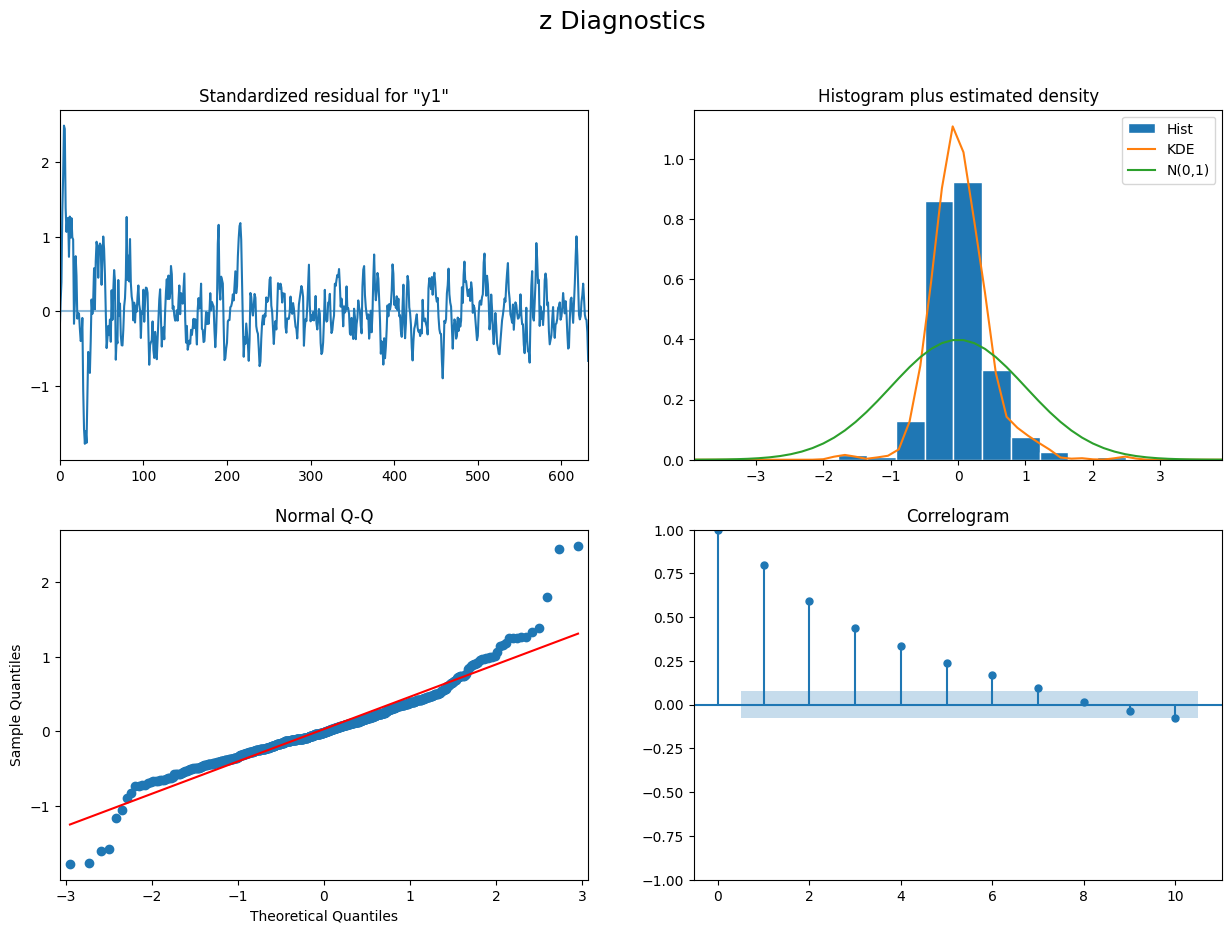

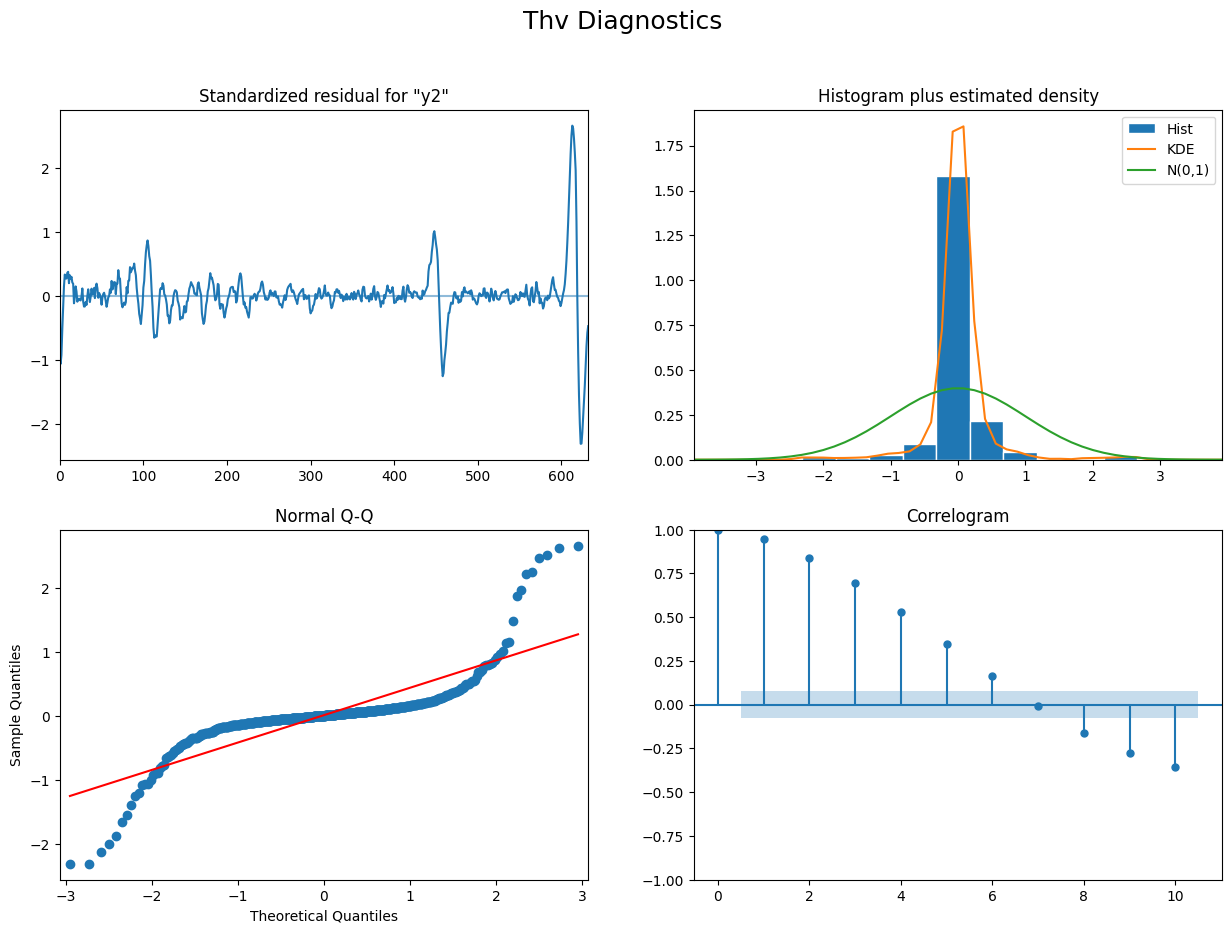

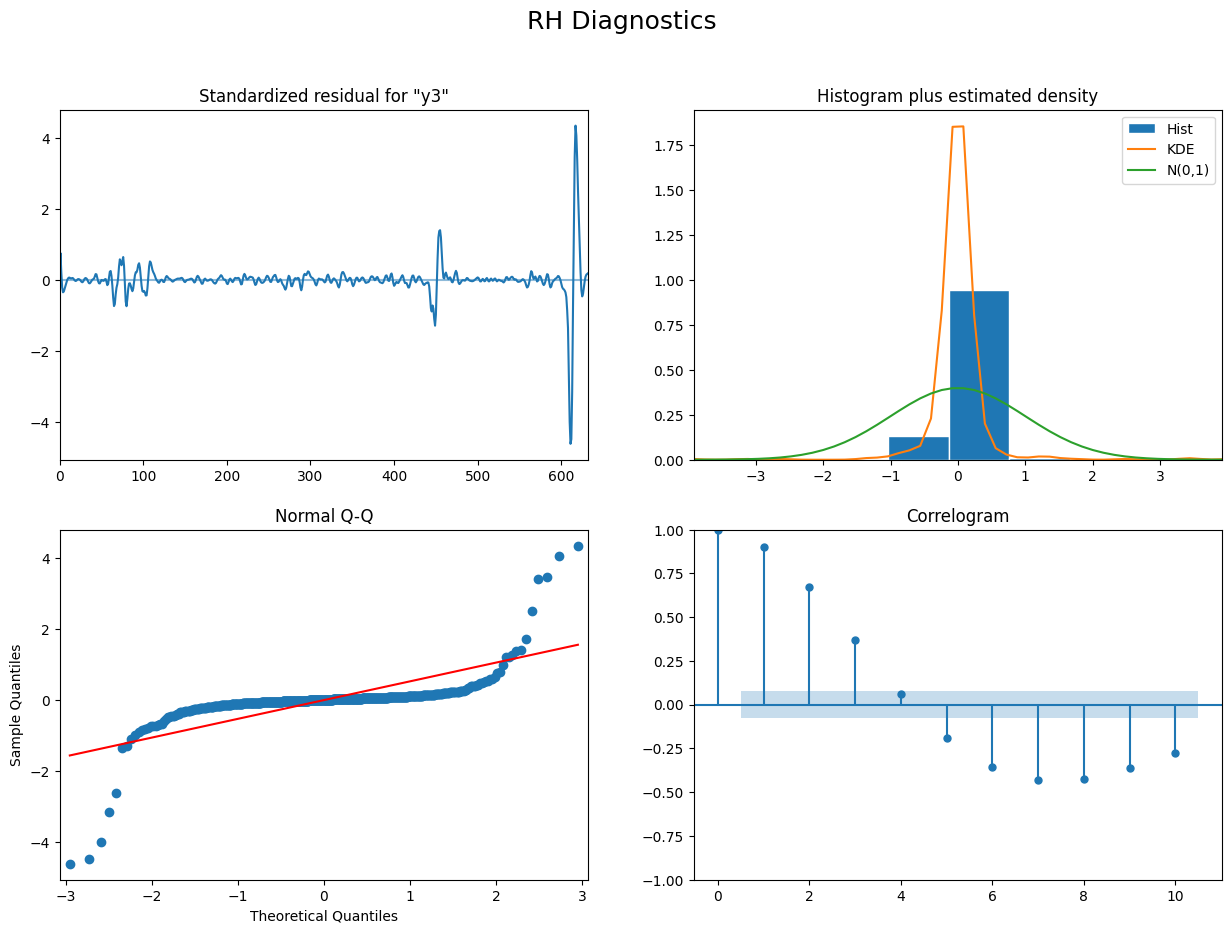

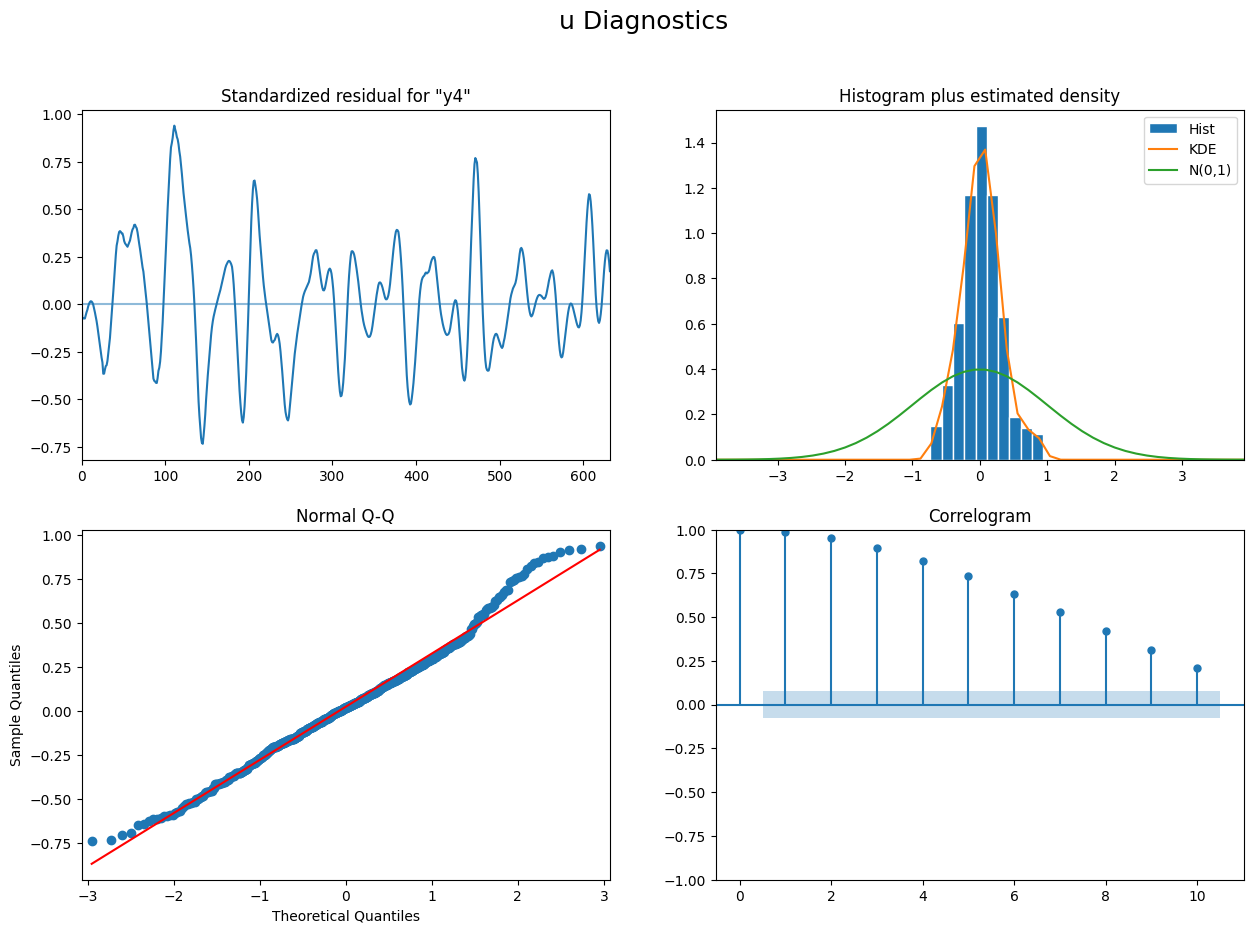

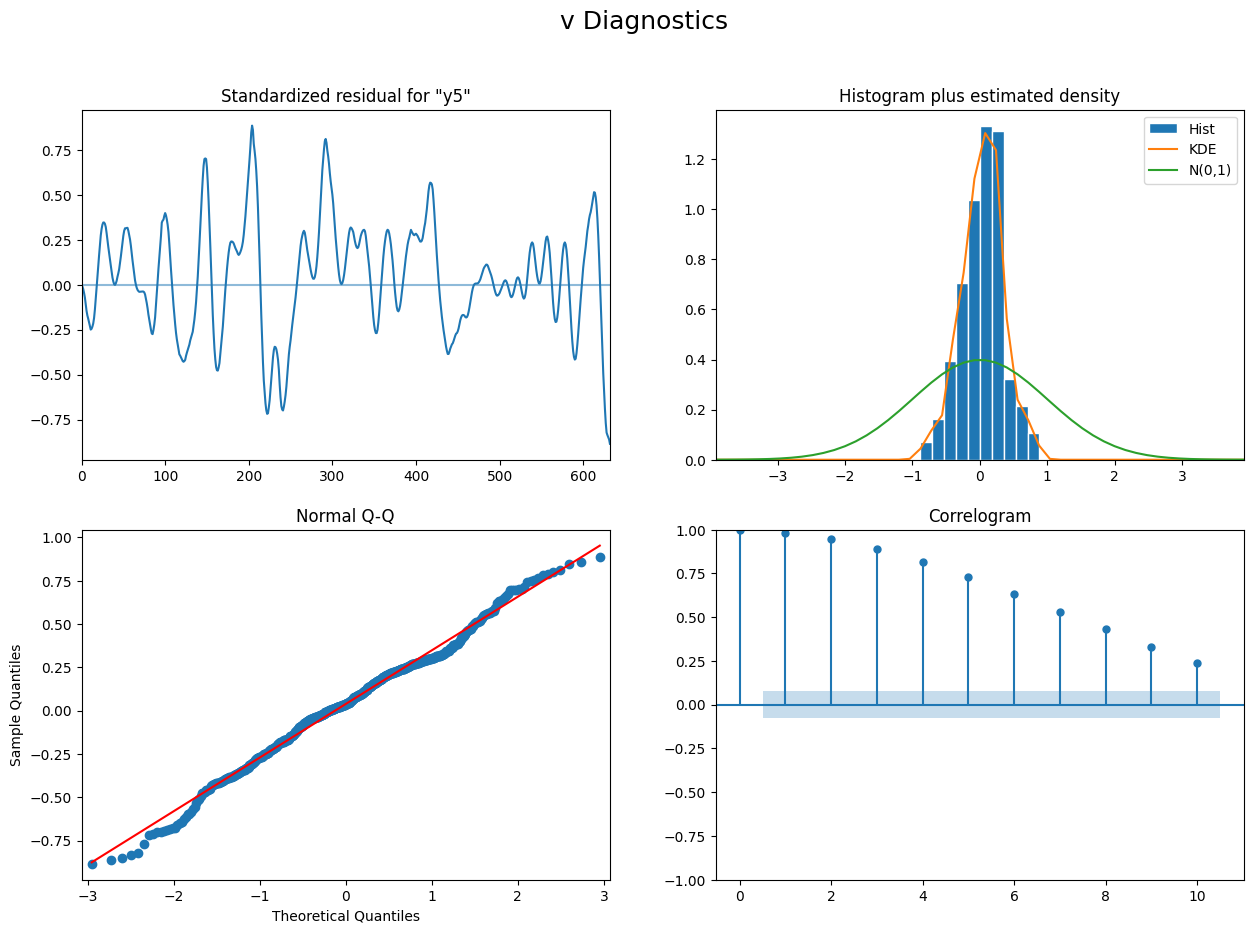

In [12]:
# - Create diagnostic figures based on standardized residuals:
#   (1) time series graph
#   (2) histogram
#   (3) Q-Q plot
#   (4) correlogram
for var in range(5):
    fig=results.plot_diagnostics(variable=var)
    fig.set_size_inches(15,10)
    fig.suptitle(f'{variables[var]} Diagnostics', fontsize=18)
    plt.show(block=True)

## Univariate Local Linear Trend with Free Measurement Unc.

In [15]:
"""
Univariate Local Linear Trend Model
"""

class UnivariateLocalLinearTrend(sm.tsa.statespace.MLEModel):
    def __init__(self, endog):
        # Model order
        k_states = k_posdef = 2

        # Initialize the statespace
        super(UnivariateLocalLinearTrend, self).__init__(
            endog,
            k_states=k_states,
            k_posdef=k_posdef,
            initialization="approximate_diffuse",
            loglikelihood_burn=k_states,
        )

        # Initialize the matrices
        self.ssm["design"] = np.array([1, 0])
        self.ssm["transition"] = np.array([[1, 1], [0, 1]])
        self.ssm["selection"] = np.eye(k_states)

        # Cache some indices
        self._state_cov_idx = ("state_cov",) + np.diag_indices(k_posdef)

    @property
    def param_names(self):
        return ["sigma2.measurement", "sigma2.level", "sigma2.trend"]

    @property
    def start_params(self):
        return [np.std(self.endog)] * 3

    def transform_params(self, unconstrained):
        return unconstrained**2

    def untransform_params(self, constrained):
        return constrained**0.5

    def update(self, params, *args, **kwargs):
        params = super(UnivariateLocalLinearTrend, self).update(params, *args, **kwargs)

        # Observation covariance
        self.ssm["obs_cov", 0, 0] = params[0]

        # State covariance
        self.ssm[self._state_cov_idx] = params[1:]

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Thu, 30 Jul 2026   AIC                           2083.334
Time:                                11:36:04   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

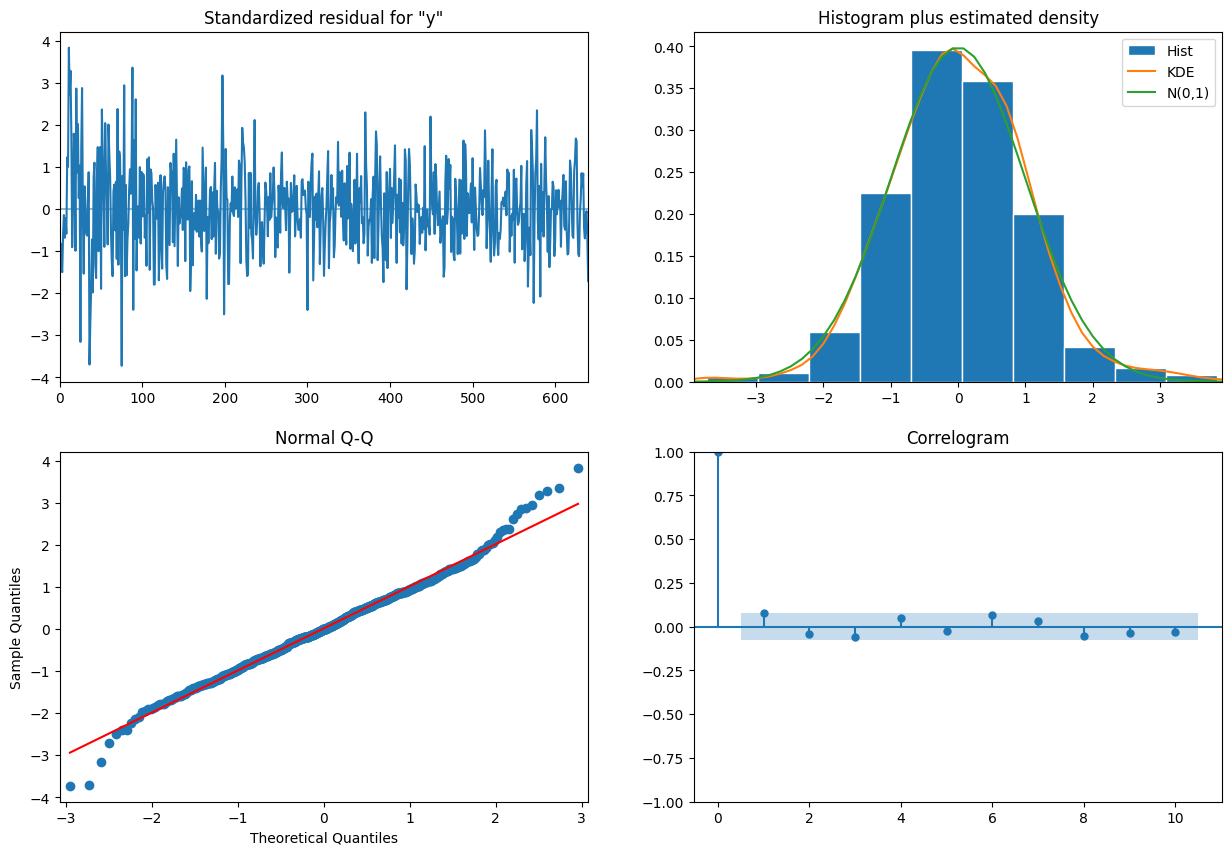

In [23]:
mod = UnivariateLocalLinearTrend(z)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

No more autocorrelated but still not normal and heteroskedastic.

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood                1224.891
Date:                        Thu, 30 Jul 2026   AIC                          -2443.782
Time:                                11:37:14   BIC                          -2430.393
Sample:                                     0   HQIC                         -2438.585
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement     0.0002   1.85e-05     12.590      0.000       0.000       0.000
sigma2.level        2.235e-11   6.12e-05   

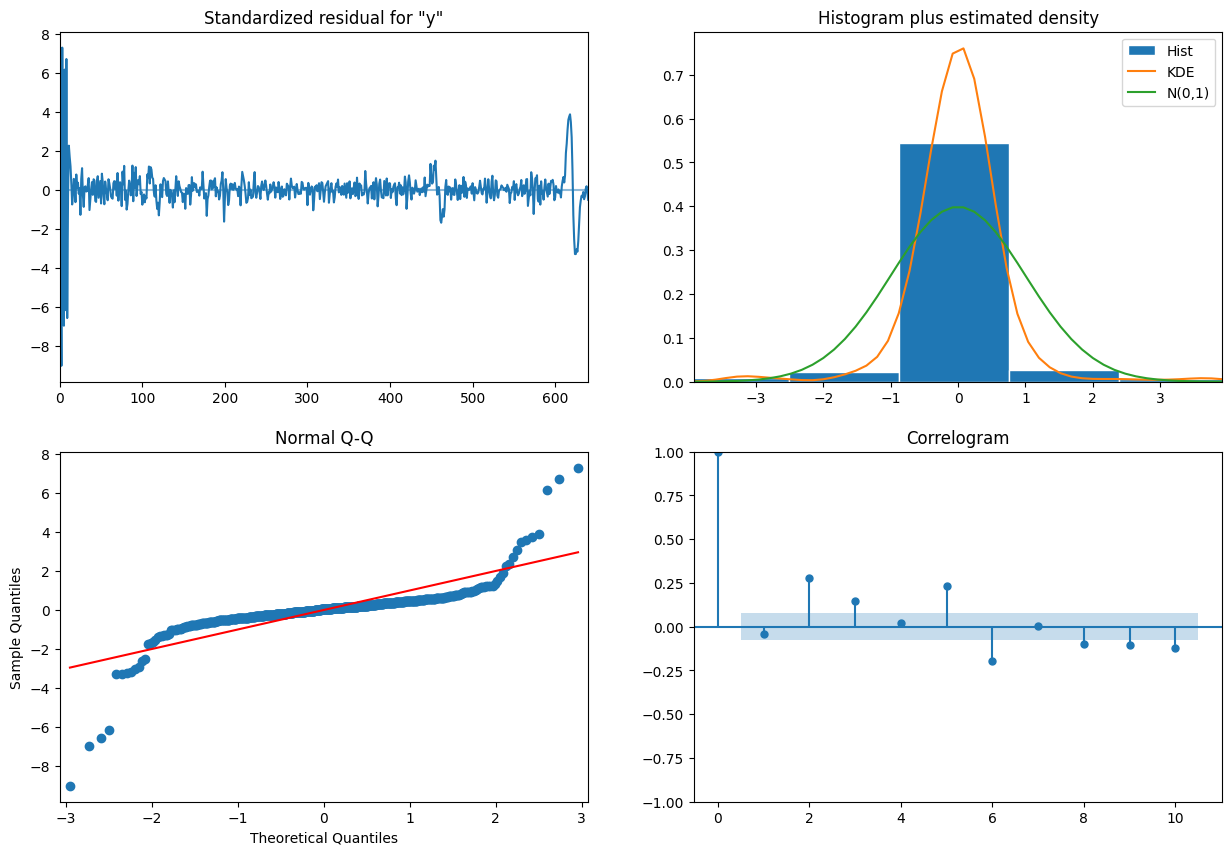

In [25]:
mod = UnivariateLocalLinearTrend(Thv)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

As before.

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood                -579.192
Date:                        Thu, 30 Jul 2026   AIC                           1164.384
Time:                                11:37:49   BIC                           1177.773
Sample:                                     0   HQIC                          1169.580
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement     0.0070      0.003      2.031      0.042       0.000       0.014
sigma2.level        3.129e-11      0.014   

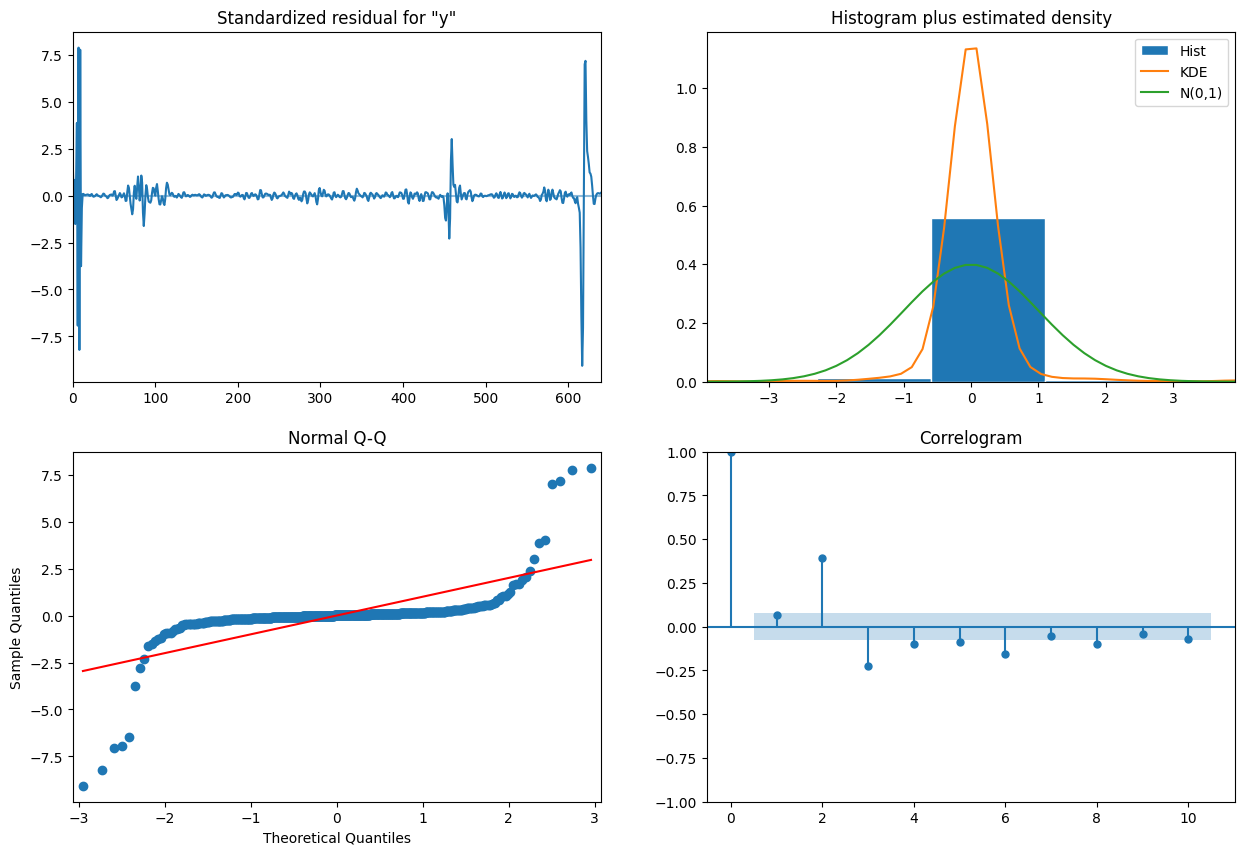

In [26]:
mod = UnivariateLocalLinearTrend(RH)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood                 916.351
Date:                        Thu, 30 Jul 2026   AIC                          -1826.701
Time:                                11:39:13   BIC                          -1813.312
Sample:                                     0   HQIC                         -1821.505
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement     0.0006   3.47e-05     17.430      0.000       0.001       0.001
sigma2.level        1.873e-11      0.000   

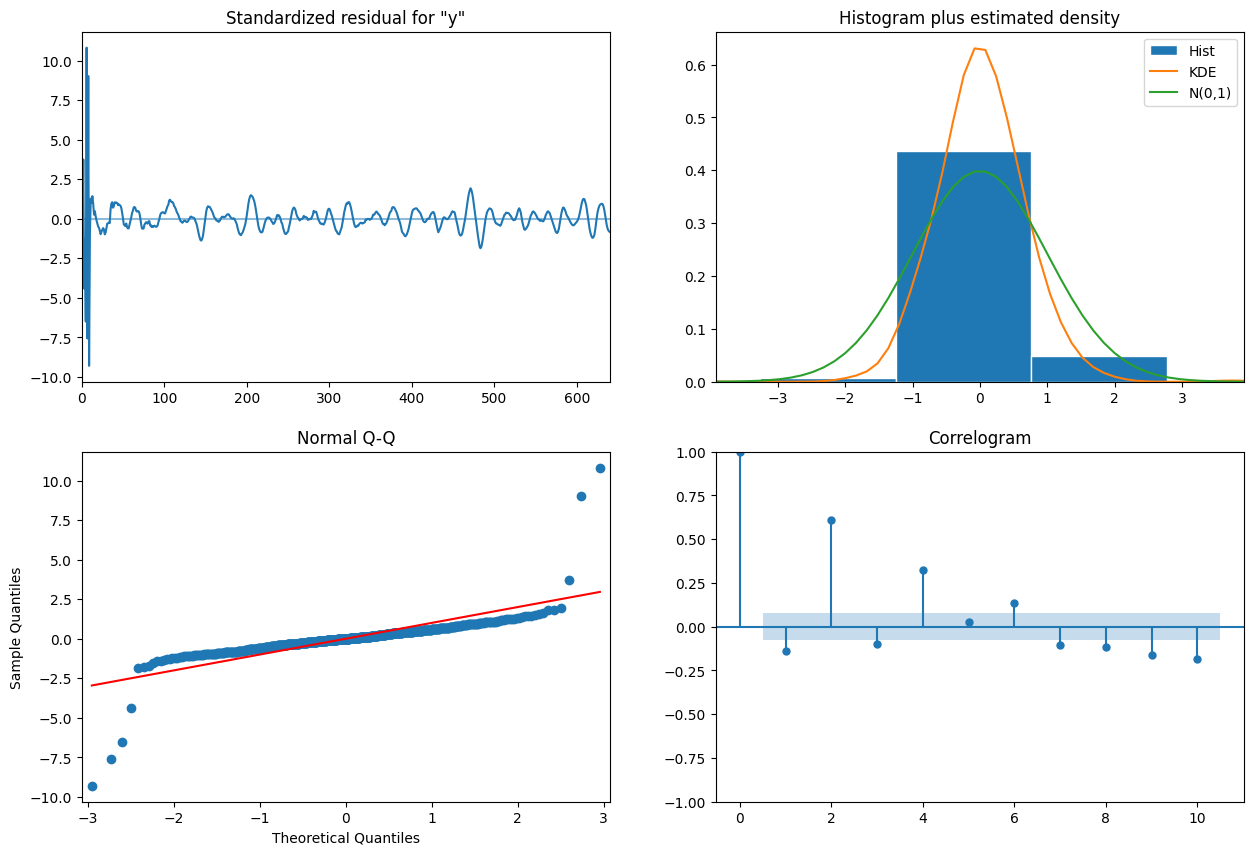

In [28]:
mod = UnivariateLocalLinearTrend(u)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood                1544.419
Date:                        Thu, 30 Jul 2026   AIC                          -3082.837
Time:                                11:39:27   BIC                          -3069.448
Sample:                                     0   HQIC                         -3077.641
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement   1.24e-11   2.86e-05   4.33e-07      1.000   -5.61e-05    5.61e-05
sigma2.level         8.76e-11   9.69e-05   

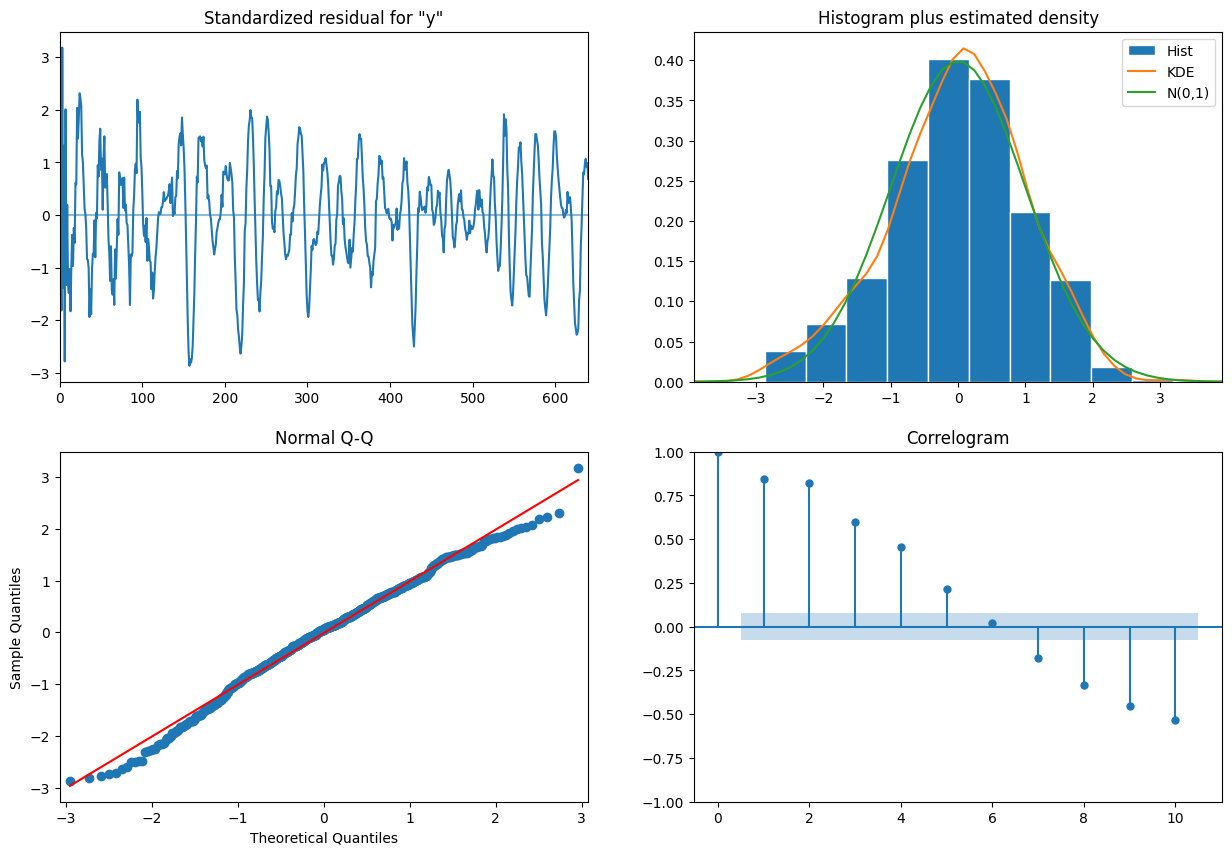

In [29]:
mod = UnivariateLocalLinearTrend(v)

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=res.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

In [18]:
# Setup the model

from ssm.statsmodels.local_level import MeasurementLocalLevel
model = MeasurementLocalLevel(endog=endog, measurement_var=measurement_var,
                         measurement_names=['alt', 'temp', 'rh', 'u', 'v'])

# Fit it using MLE with a fixed sequence of measurement variances
results = model.fit(method='powell',
            maxiter=100,
            full_output=1,
            disp=5)

Optimization terminated successfully.
         Current function value: 8.413188
         Iterations: 3
         Function evaluations: 203


In [19]:
# - Print a table summarizing estimation results
print(results.summary())


                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  643
Model:                      MeasurementLocalLevel   Log Likelihood               -5409.680
Date:                            Wed, 29 Jul 2026   AIC                          10829.359
Time:                                    17:07:28   BIC                          10851.651
Sample:                                         0   HQIC                         10838.013
                                            - 643                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
alt_sigma2.level     47.5582     17.920      2.654      0.008      12.436      82.680
temp_sigma2.le

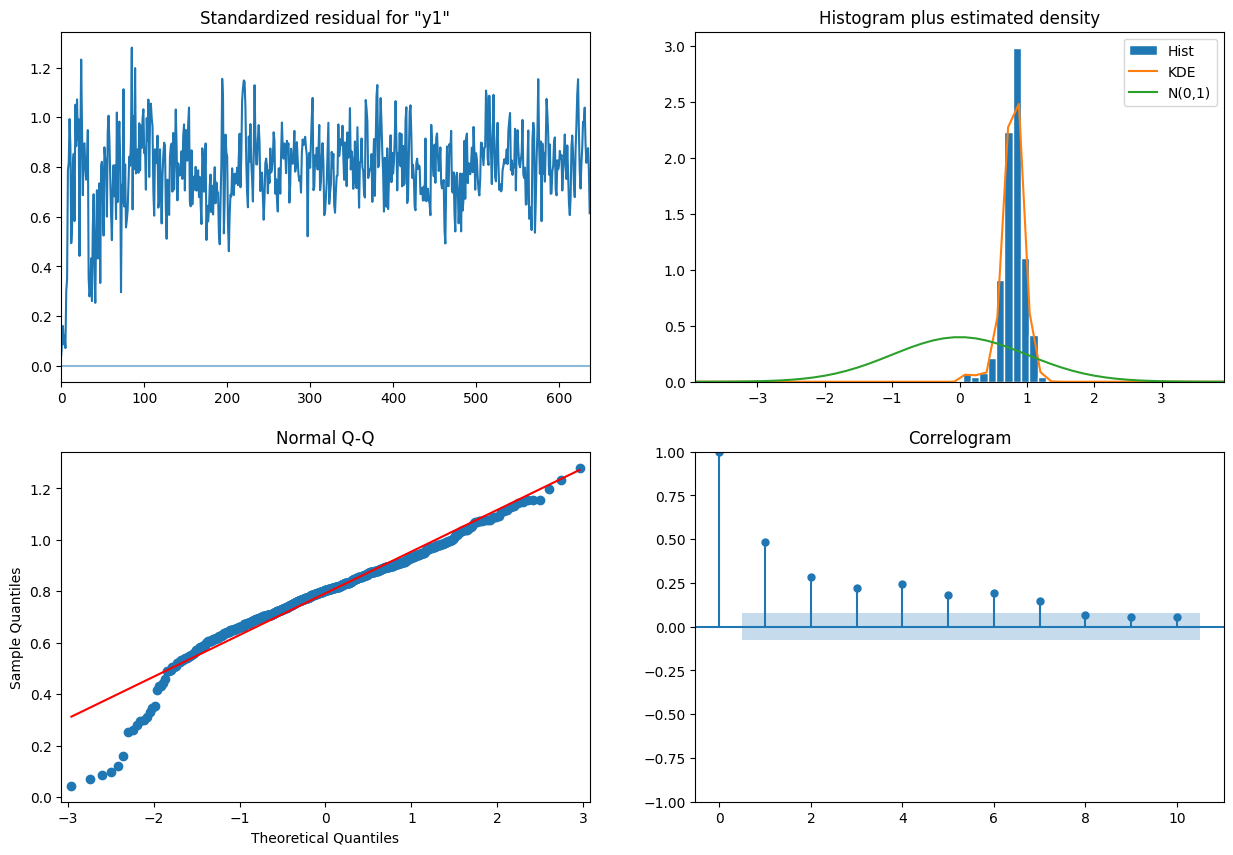

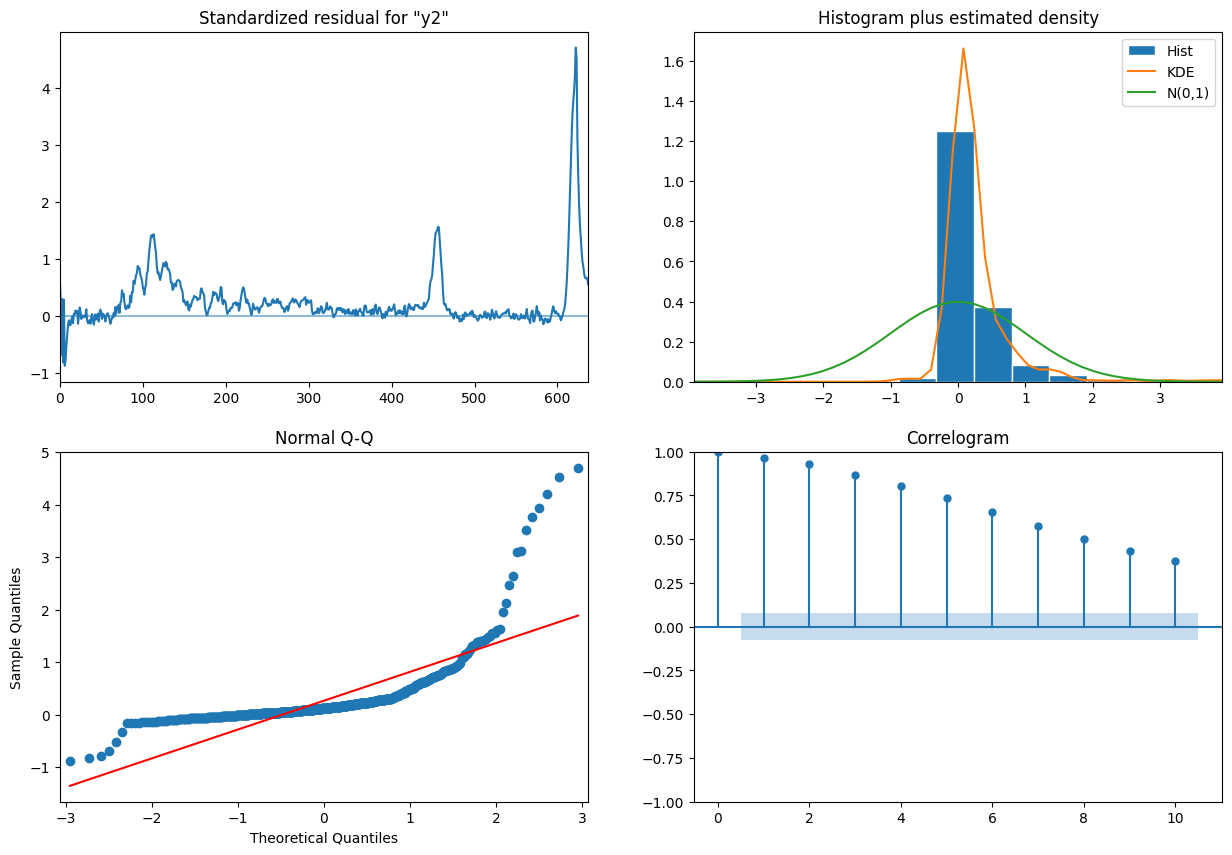

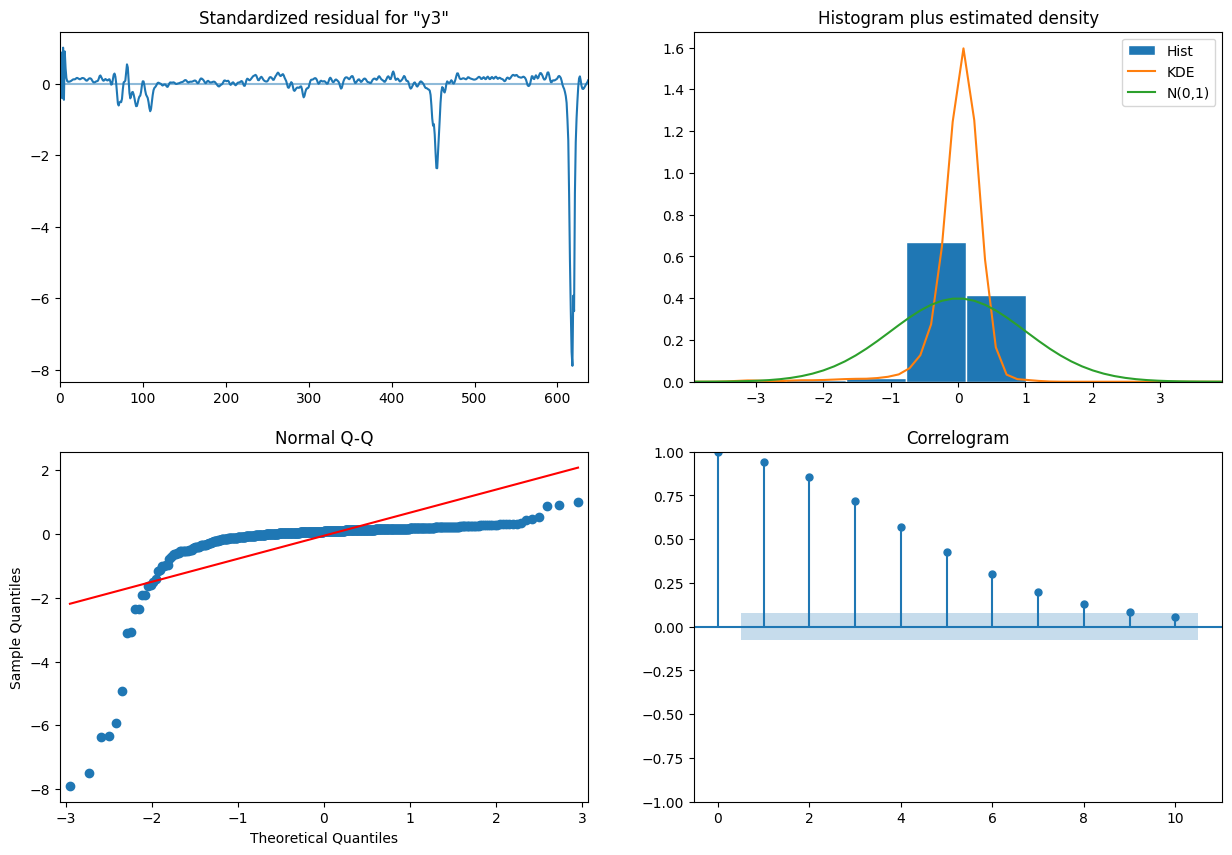

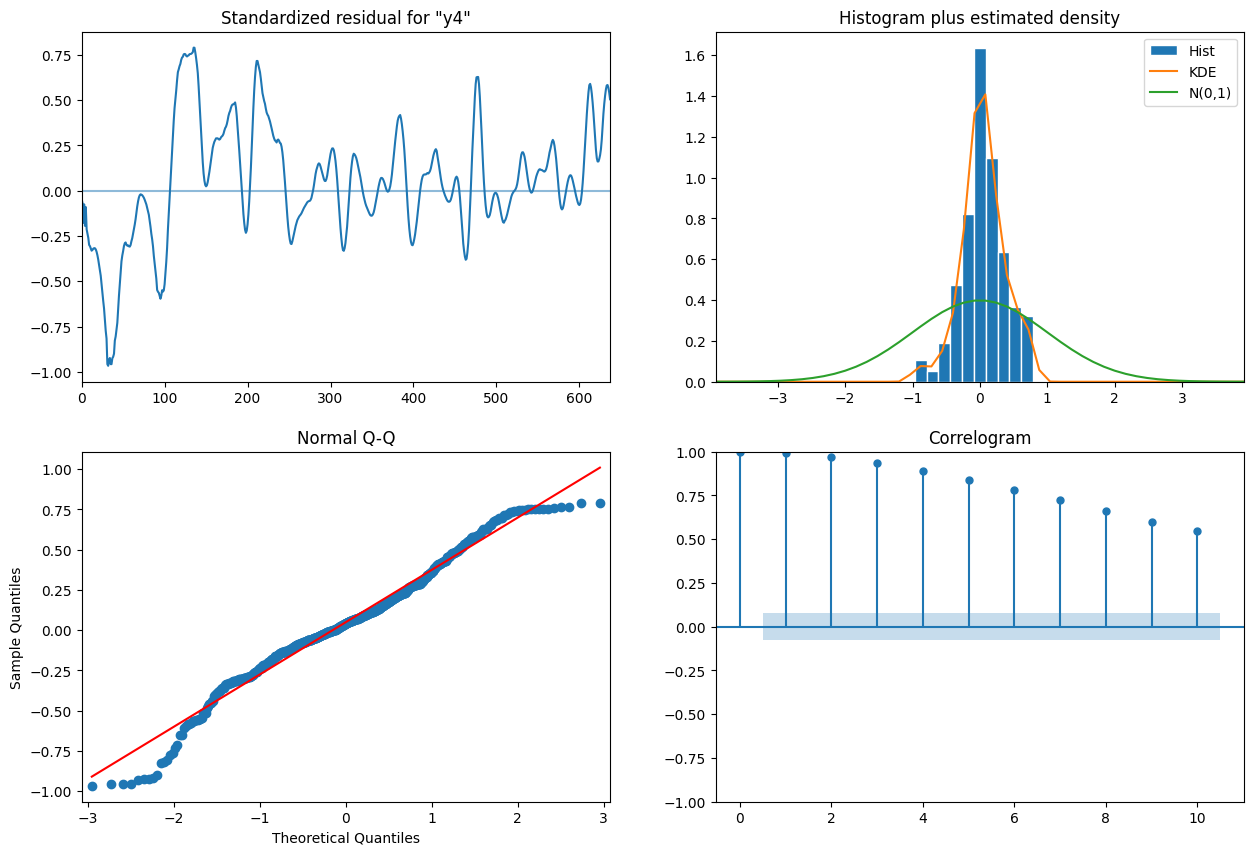

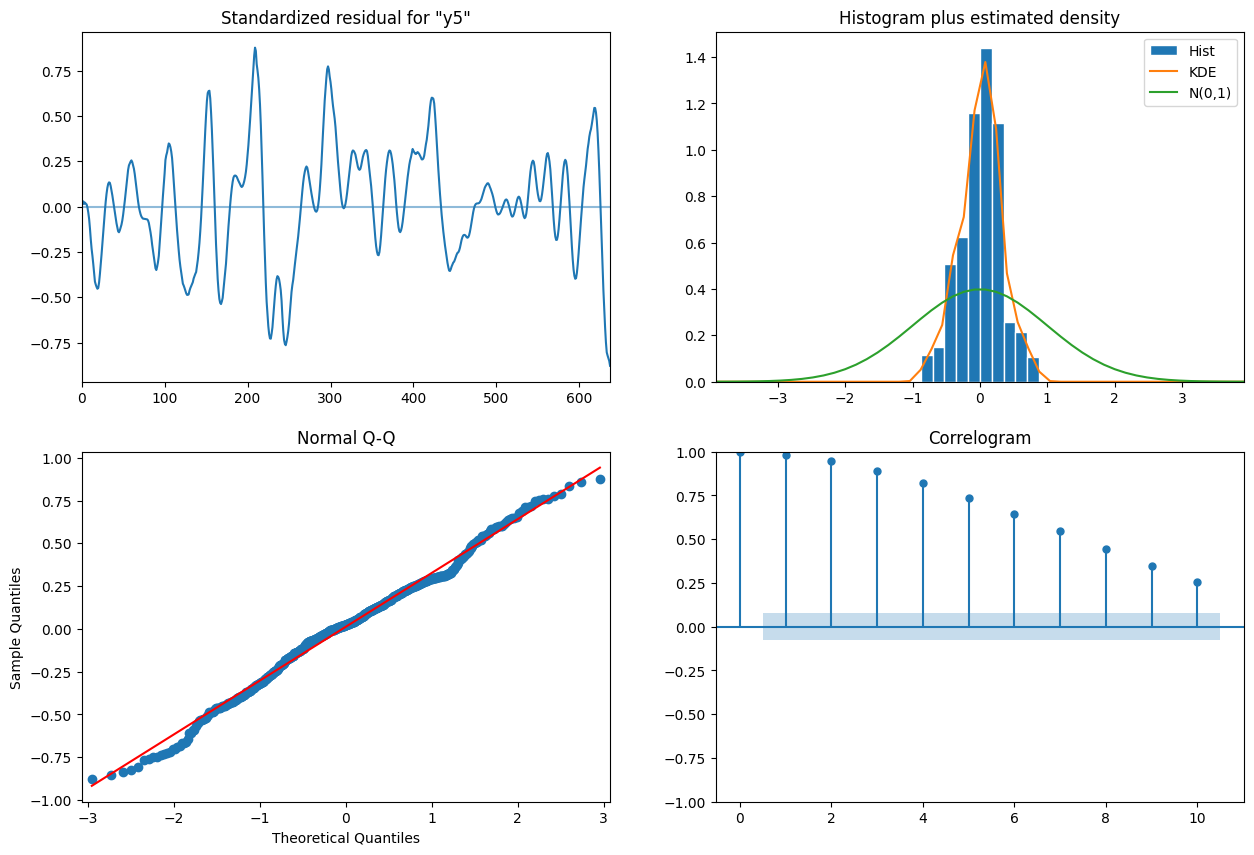

In [20]:
# - Create diagnostic figures based on standardized residuals:
#   (1) time series graph
#   (2) histogram
#   (3) Q-Q plot
#   (4) correlogram
for var in range(5):
    fig=results.plot_diagnostics(variable=var)
    fig.set_size_inches(15,10)
    plt.show(block=True)

In [21]:
"""
Univariate Local Linear Trend Model
"""


class UnivariateLocalLinearTrend(sm.tsa.statespace.MLEModel):
    def __init__(self, endog):
        # Model order
        k_states = k_posdef = 2

        # Initialize the statespace
        super(UnivariateLocalLinearTrend, self).__init__(
            endog,
            k_states=k_states,
            k_posdef=k_posdef,
            initialization="approximate_diffuse",
            loglikelihood_burn=k_states,
        )

        # Initialize the matrices
        self.ssm["design"] = np.array([1, 0])
        self.ssm["transition"] = np.array([[1, 1], [0, 1]])
        self.ssm["selection"] = np.eye(k_states)

        # Cache some indices
        self._state_cov_idx = ("state_cov",) + np.diag_indices(k_posdef)

    @property
    def param_names(self):
        return ["sigma2.measurement", "sigma2.level", "sigma2.trend"]

    @property
    def start_params(self):
        return [np.std(self.endog)] * 3

    def transform_params(self, unconstrained):
        return unconstrained**2

    def untransform_params(self, constrained):
        return constrained**0.5

    def update(self, params, *args, **kwargs):
        params = super(UnivariateLocalLinearTrend, self).update(params, *args, **kwargs)

        # Observation covariance
        self.ssm["obs_cov", 0, 0] = params[0]

        # State covariance
        self.ssm[self._state_cov_idx] = params[1:]

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                17:07:34   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

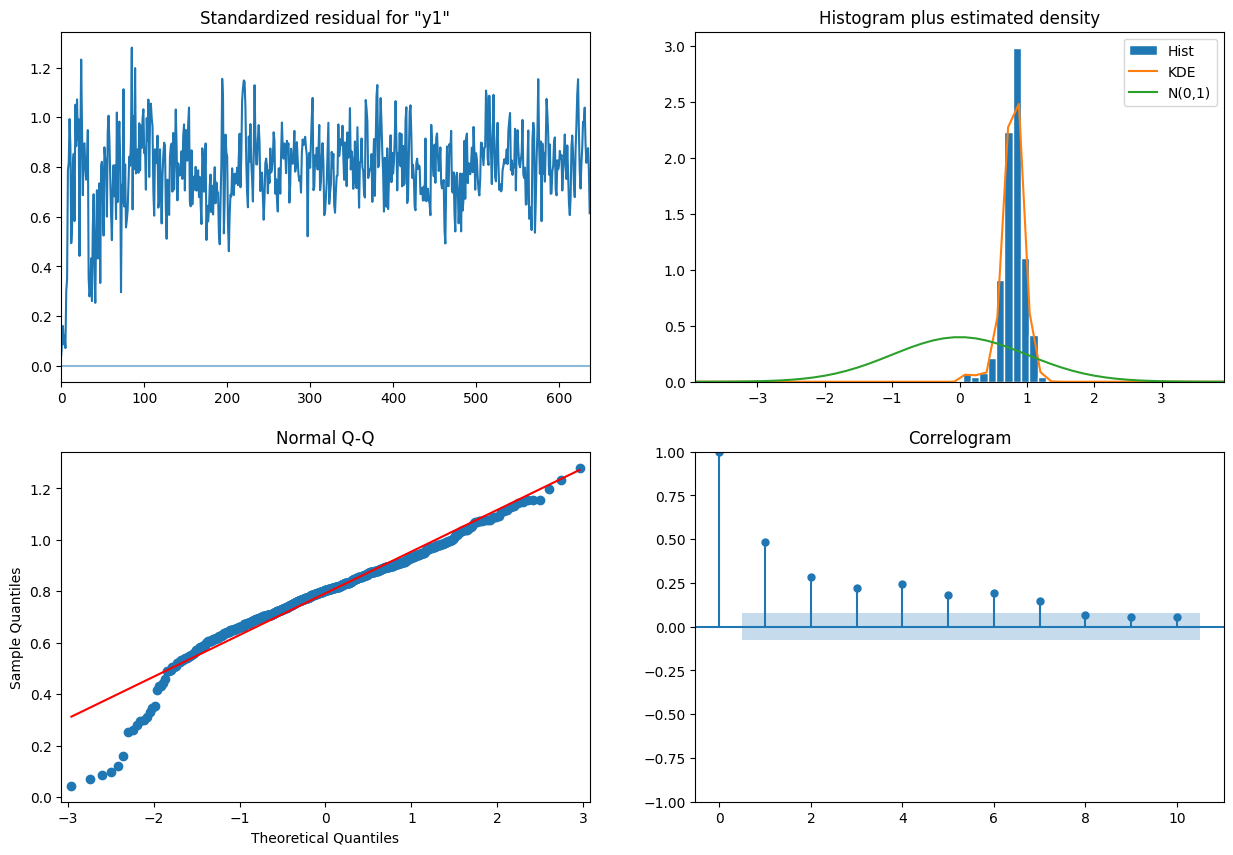

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                17:07:34   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

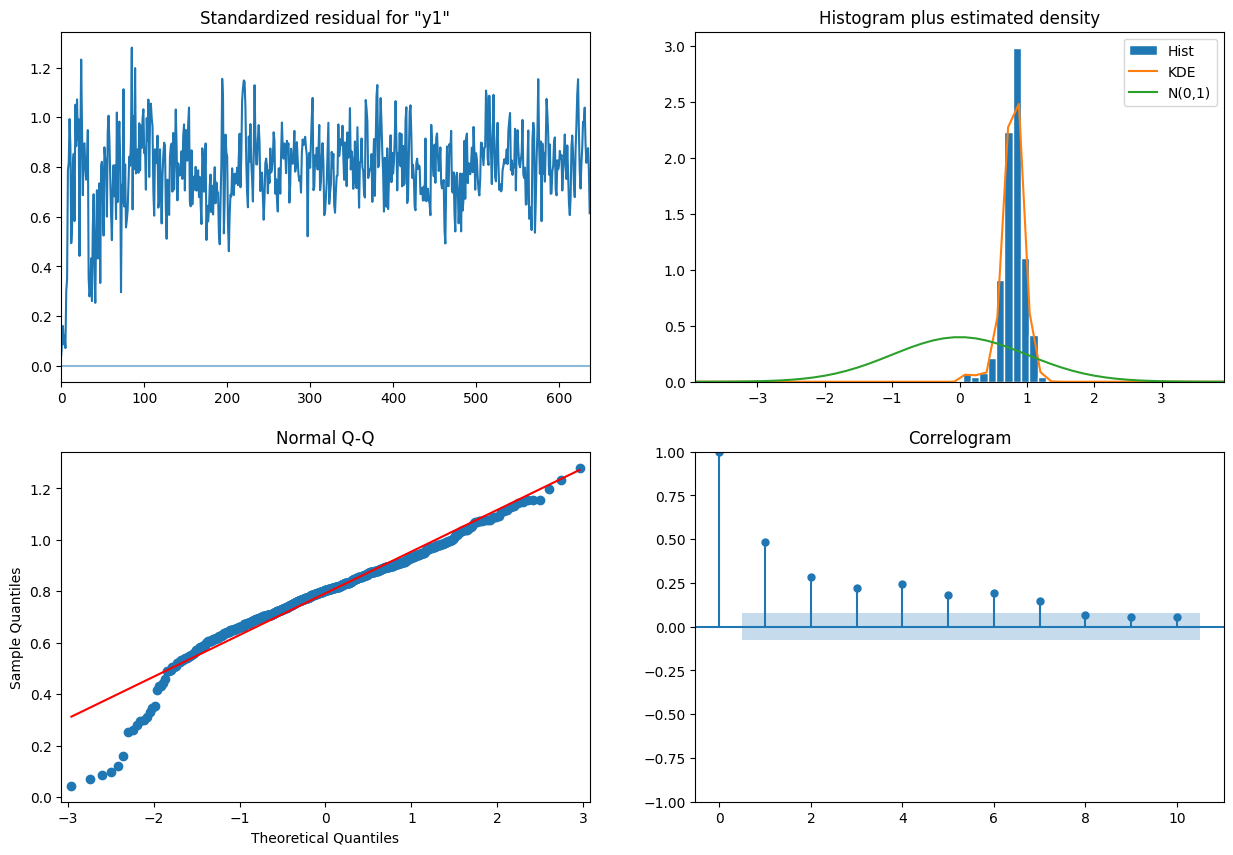

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                17:07:35   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

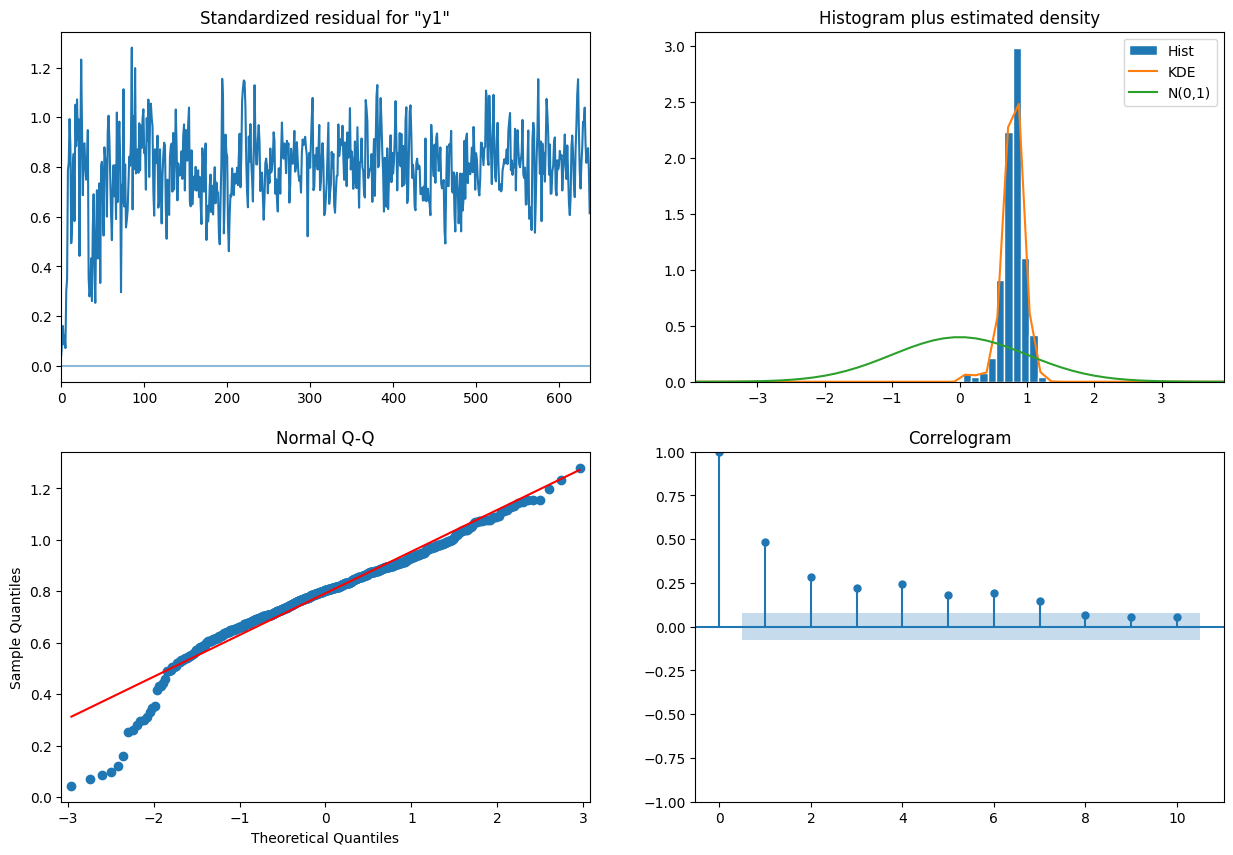

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                17:07:35   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

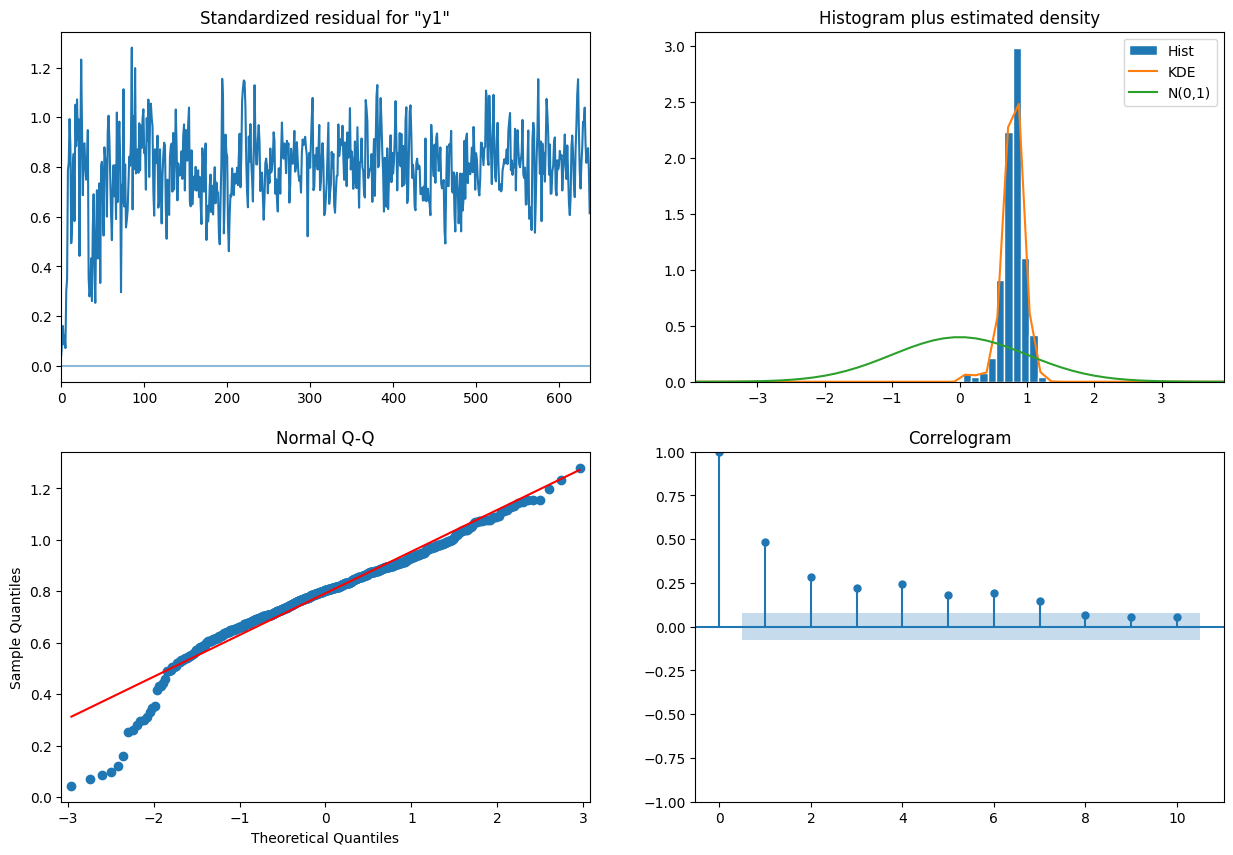

                               Statespace Model Results                               
Dep. Variable:                              y   No. Observations:                  643
Model:             UnivariateLocalLinearTrend   Log Likelihood               -1038.667
Date:                        Wed, 29 Jul 2026   AIC                           2083.334
Time:                                17:07:36   BIC                           2096.723
Sample:                                     0   HQIC                          2088.531
                                        - 643                                         
Covariance Type:                          opg                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2.measurement  1.483e-11      0.048   3.07e-10      1.000      -0.095       0.095
sigma2.level           1.2222      0.125   

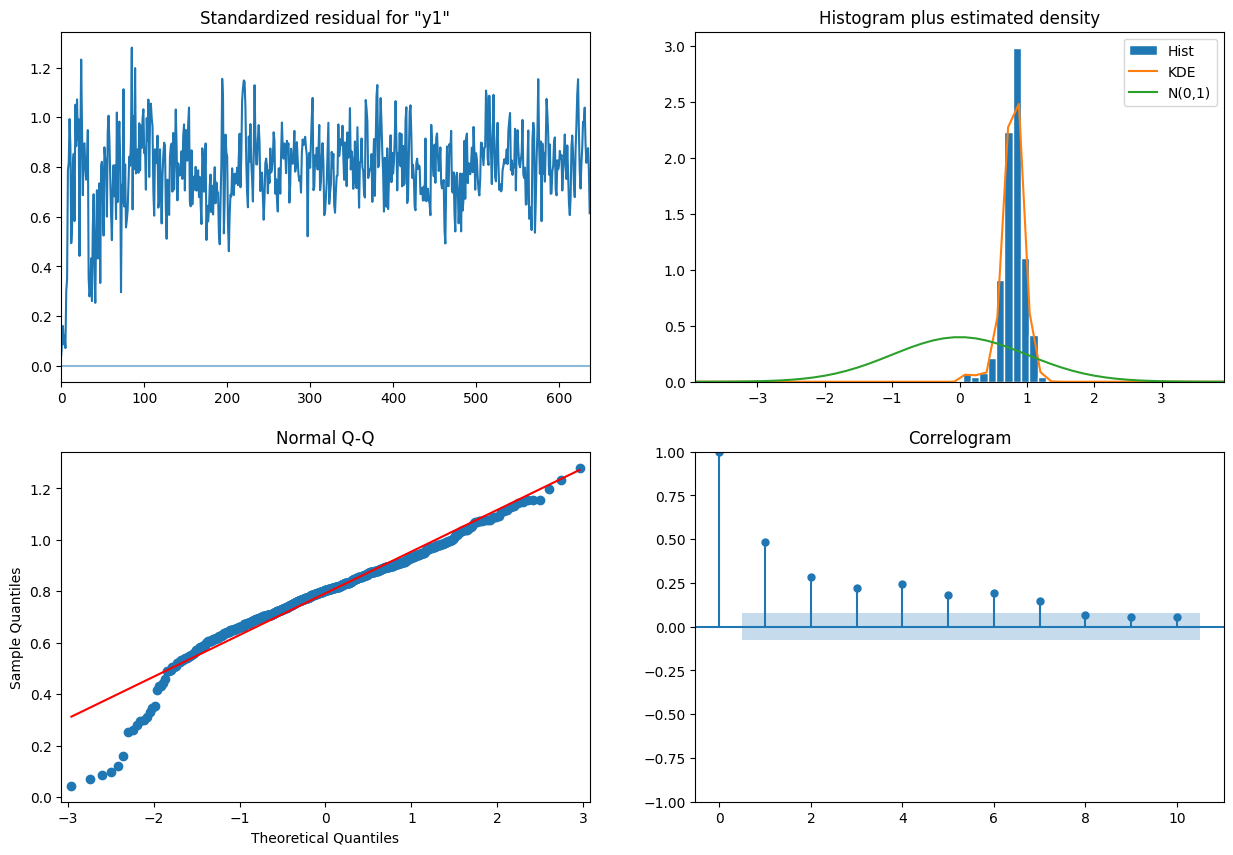

In [22]:
for var in [z, Thv, RH, u, v]:
    # Setup the model
    mod = UnivariateLocalLinearTrend(z)

    # Fit it using MLE (recall that we are fitting the three variance parameters)
    res = mod.fit(disp=False)
    print(res.summary())
    fig=results.plot_diagnostics()
    fig.set_size_inches(15,10)
    plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1032.076
Date:                Wed, 29 Jul 2026   AIC                           2072.151
Time:                        17:20:49   BIC                           2090.010
Sample:                             0   HQIC                          2079.082
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5437      0.127      4.280      0.000       0.295       0.793
ar.L1          0.8995      0.024     37.397      0.000       0.852       0.947
ma.L1         -0.7016      0.040    -17.346      0.0

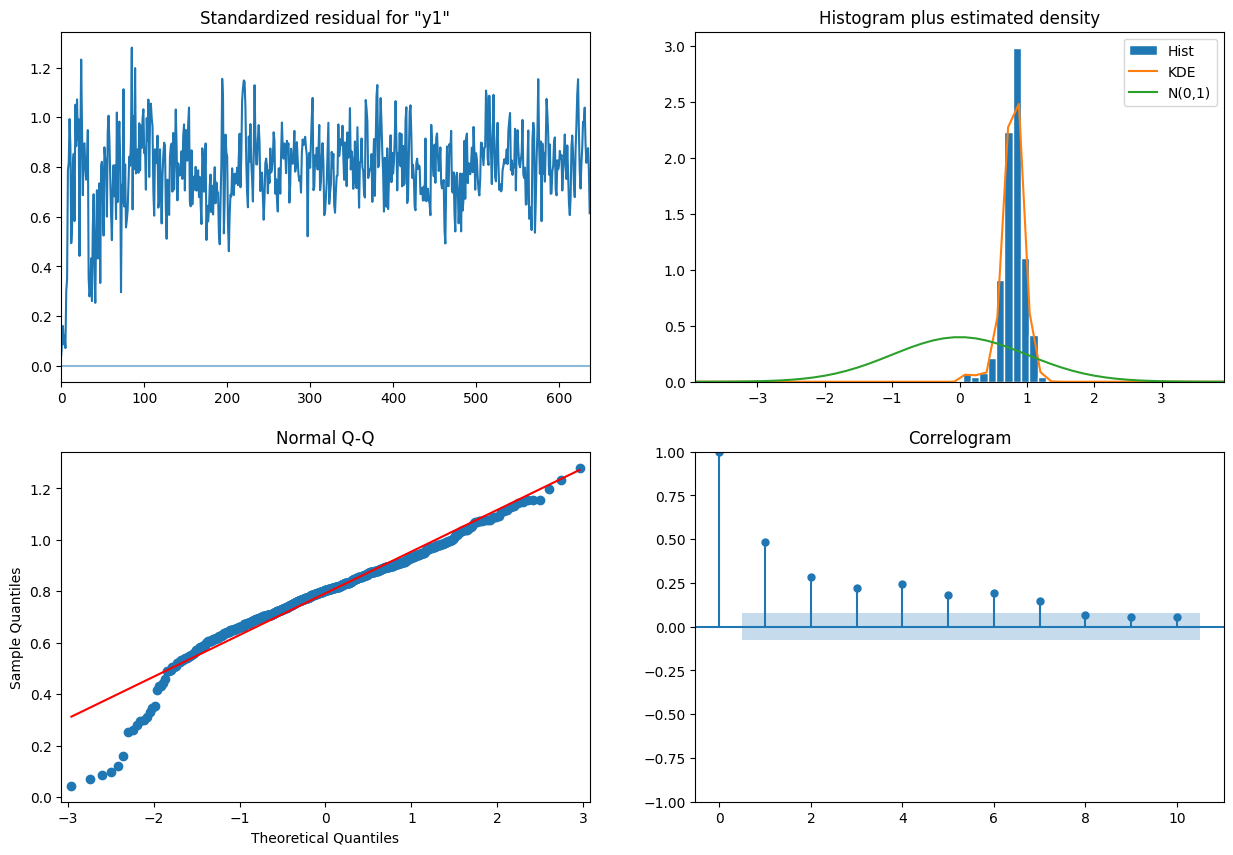

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                1194.945
Date:                Wed, 29 Jul 2026   AIC                          -2381.890
Time:                        17:20:50   BIC                          -2364.031
Sample:                             0   HQIC                         -2374.959
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0017      0.001      1.786      0.074      -0.000       0.004
ar.L1          0.9502      0.008    119.789      0.000       0.935       0.966
ma.L1         -0.4534      0.013    -34.812      0.0

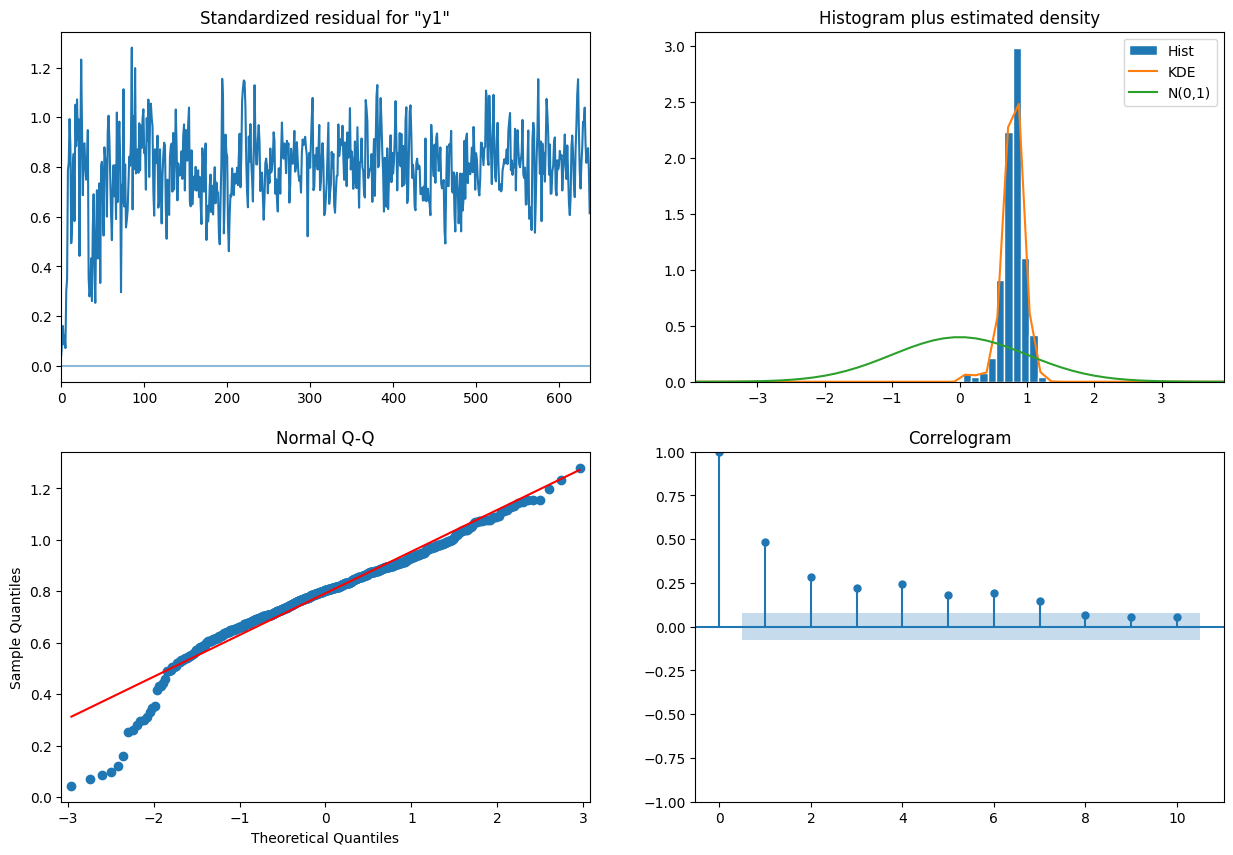

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -566.693
Date:                Wed, 29 Jul 2026   AIC                           1141.387
Time:                        17:20:50   BIC                           1159.245
Sample:                             0   HQIC                          1148.317
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0120      0.029     -0.413      0.680      -0.069       0.045
ar.L1          0.8920      0.006    152.503      0.000       0.881       0.903
ma.L1          0.0035      0.009      0.412      0.6

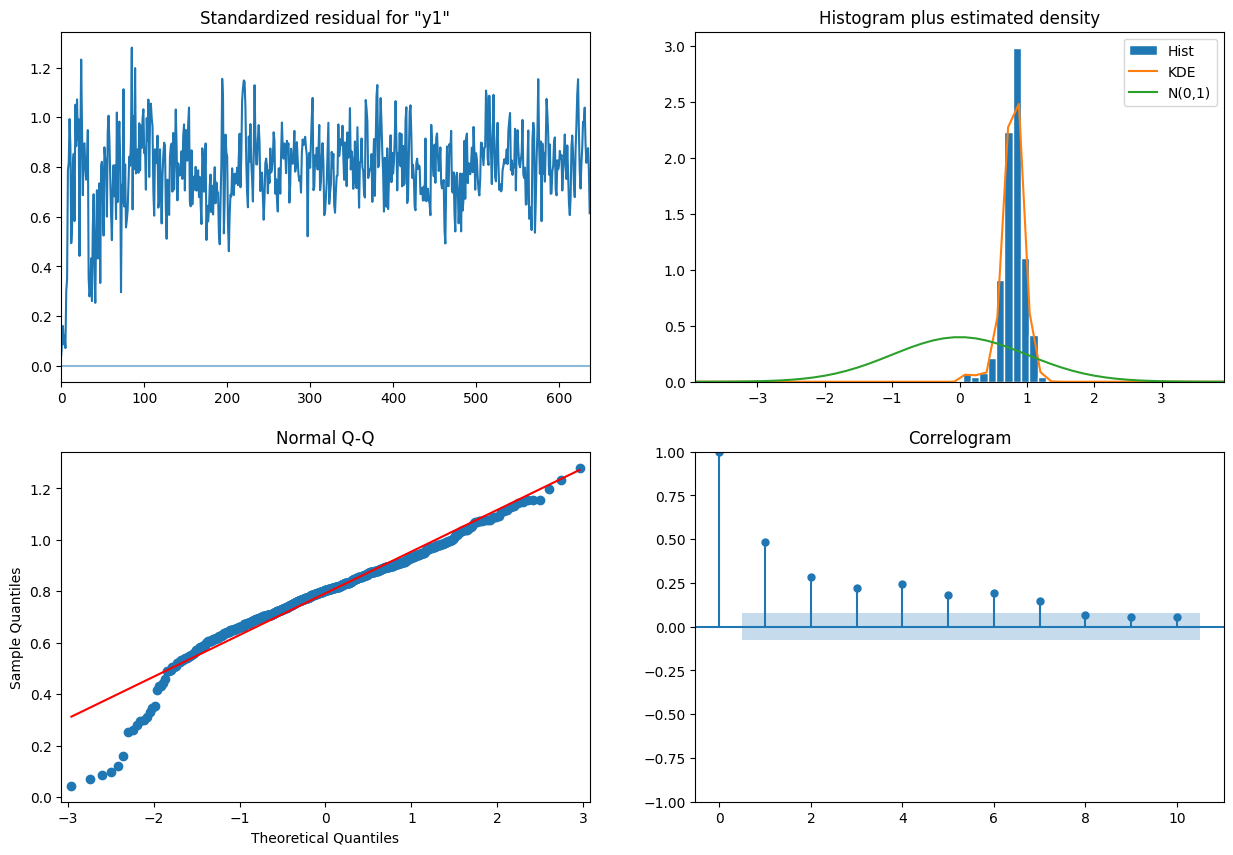

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 860.250
Date:                Wed, 29 Jul 2026   AIC                          -1712.499
Time:                        17:20:51   BIC                          -1694.641
Sample:                             0   HQIC                         -1705.568
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0007      0.002      0.389      0.697      -0.003       0.004
ar.L1          0.9570      0.015     62.395      0.000       0.927       0.987
ma.L1         -0.4475      0.025    -17.869      0.0

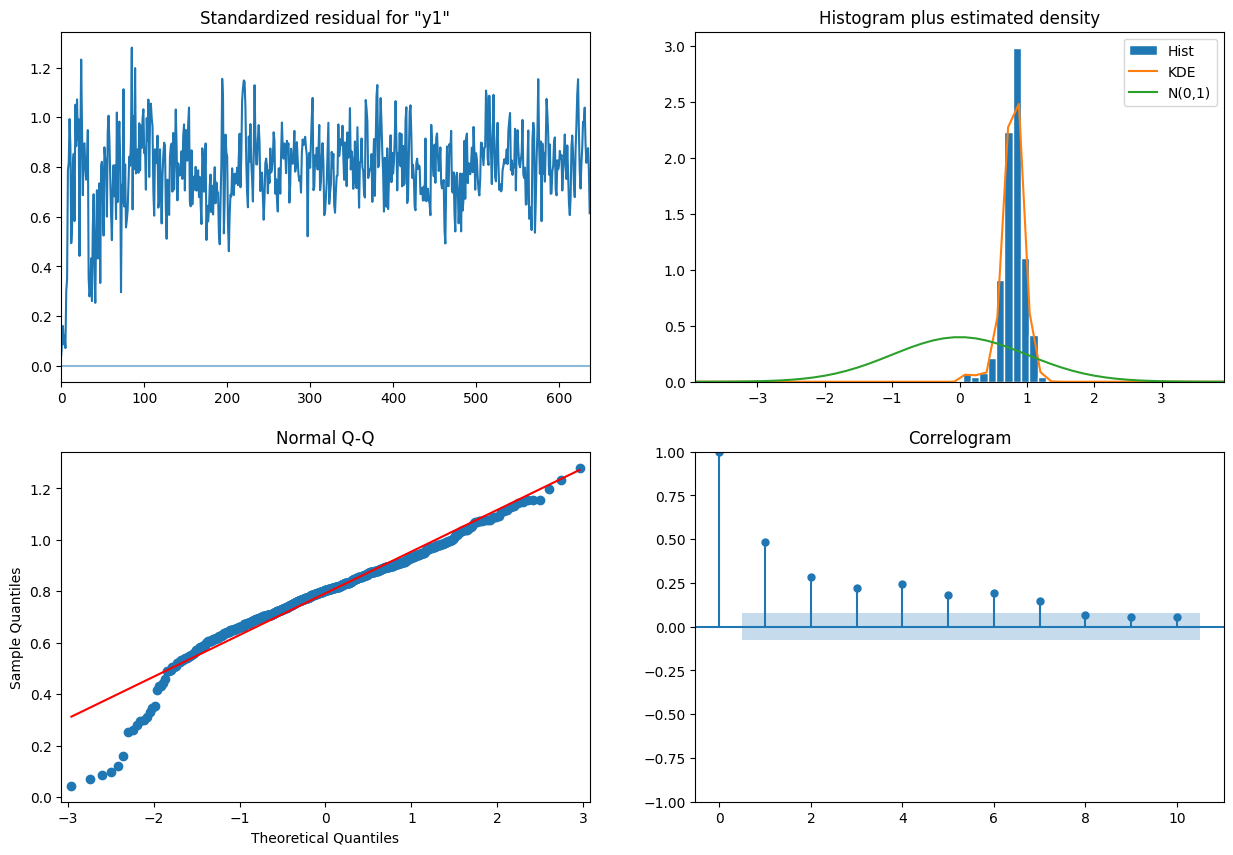

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                1706.633
Date:                Wed, 29 Jul 2026   AIC                          -3405.265
Time:                        17:20:51   BIC                          -3387.407
Sample:                             0   HQIC                         -3398.335
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0001      0.001     -0.111      0.912      -0.002       0.002
ar.L1          0.9693      0.011     90.245      0.000       0.948       0.990
ma.L1          0.5031      0.016     31.808      0.0

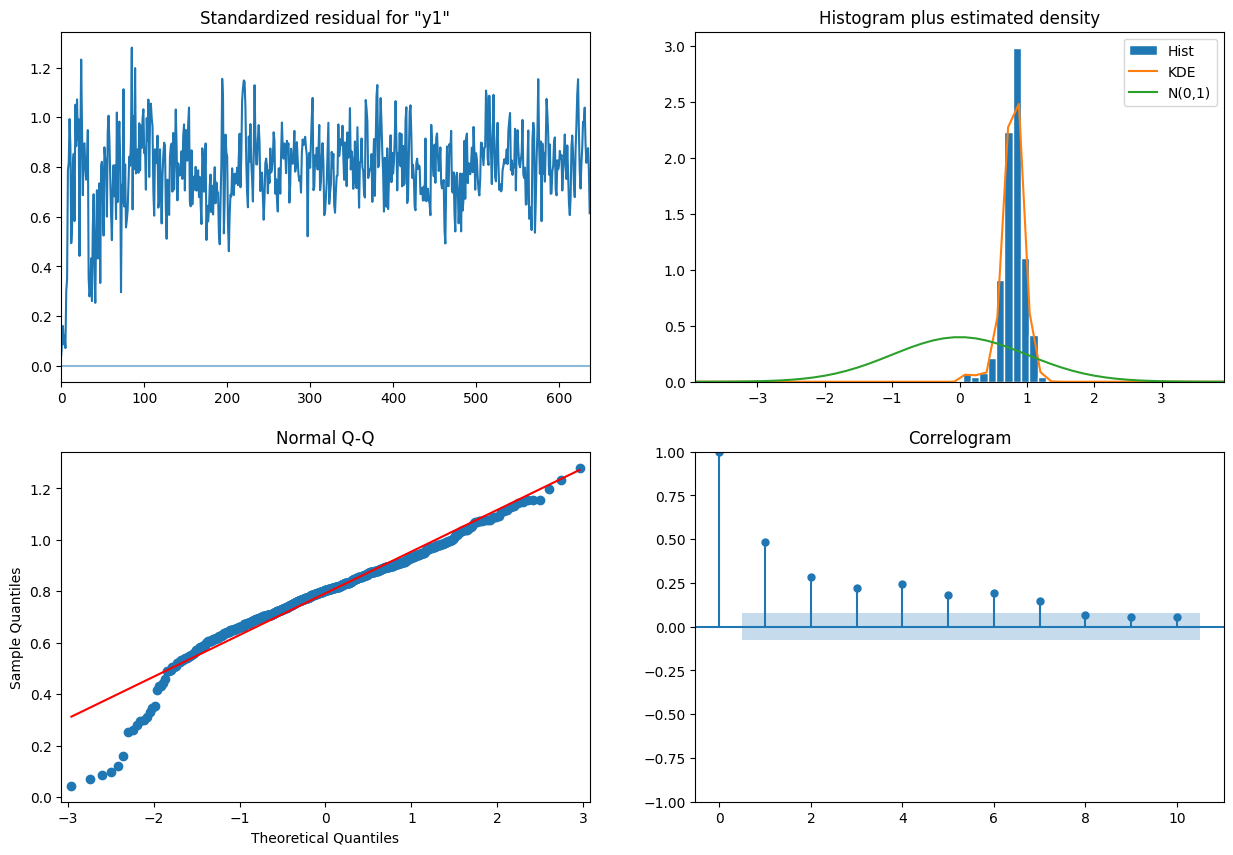

In [40]:
for var in [z, Thv, RH, u, v]:
    # Setup the model
    mod = sm.tsa.statespace.SARIMAX(var, trend='c', order=(1,1,1))

    # Fit it using MLE (recall that we are fitting the three variance parameters)
    res = mod.fit(disp=False)
    print(res.summary())
    fig=results.plot_diagnostics()
    fig.set_size_inches(15,10)
    plt.show(block=True)


                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood               -2019.924
Date:                Wed, 29 Jul 2026   AIC                           4045.847
Time:                        17:07:42   BIC                           4059.246
Sample:                             0   HQIC                          4051.047
                                - 643   Scale                           31.341
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.040     25.260      0.000       0.922       1.077
initial_level      61.3814   4.82e+04      0.001      0.999   -9.44e+04    9.45e+04
Ljung-Box (L1) (Q):             

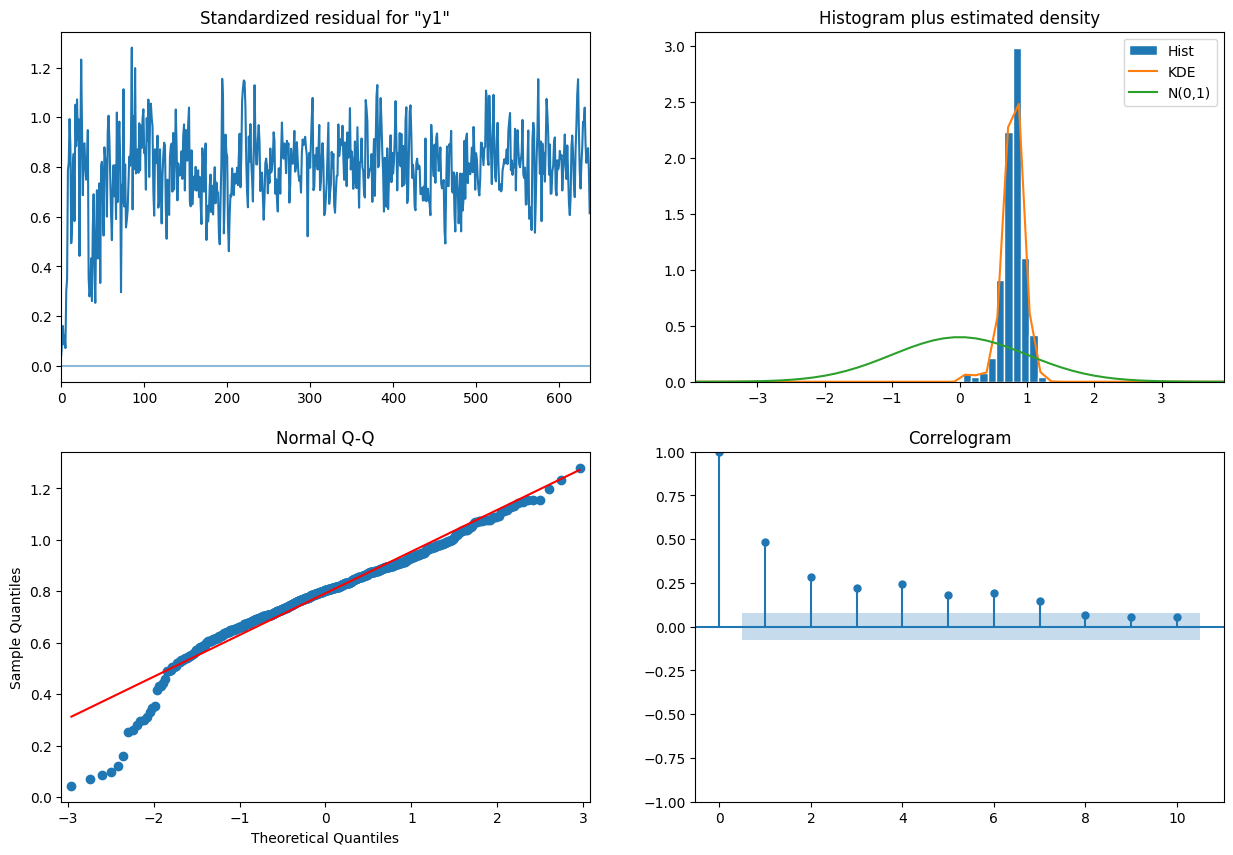

                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood                 749.879
Date:                Wed, 29 Jul 2026   AIC                          -1493.759
Time:                        17:07:43   BIC                          -1480.360
Sample:                             0   HQIC                         -1488.559
                                - 643   Scale                            0.006
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.021     46.928      0.000       0.958       1.042
initial_level     292.1886    141.937      2.059      0.040      13.997     570.380
Ljung-Box (L1) (Q):             

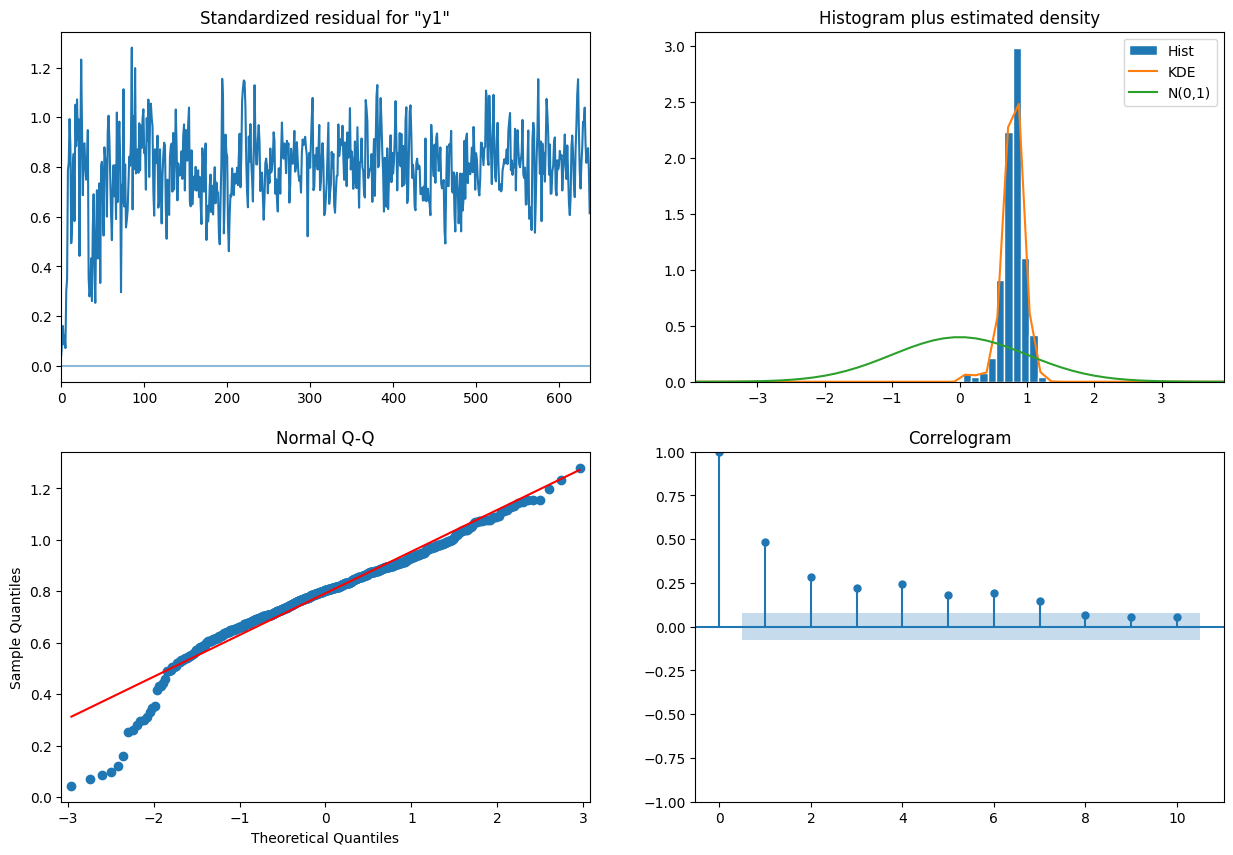

                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood               -1083.542
Date:                Wed, 29 Jul 2026   AIC                           2173.085
Time:                        17:07:43   BIC                           2186.483
Sample:                             0   HQIC                          2178.284
                                - 643   Scale                            1.703
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.015     64.522      0.000       0.970       1.030
initial_level      73.0296    241.987      0.302      0.763    -401.256     547.315
Ljung-Box (L1) (Q):             

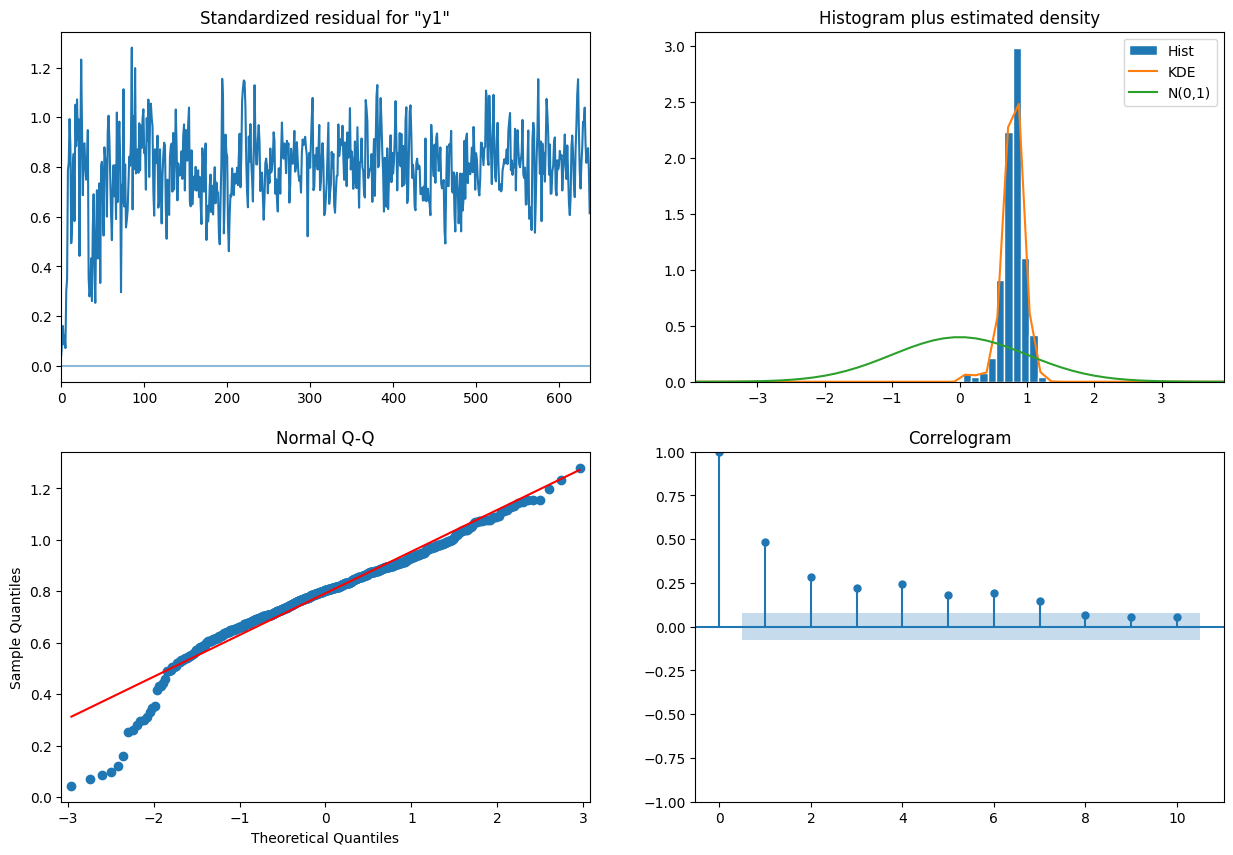

                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood                 402.057
Date:                Wed, 29 Jul 2026   AIC                           -798.113
Time:                        17:07:44   BIC                           -784.715
Sample:                             0   HQIC                          -792.914
                                - 643   Scale                            0.017
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.019     51.618      0.000       0.962       1.038
initial_level      -0.5876   2774.402     -0.000      1.000   -5438.315    5437.140
Ljung-Box (L1) (Q):             

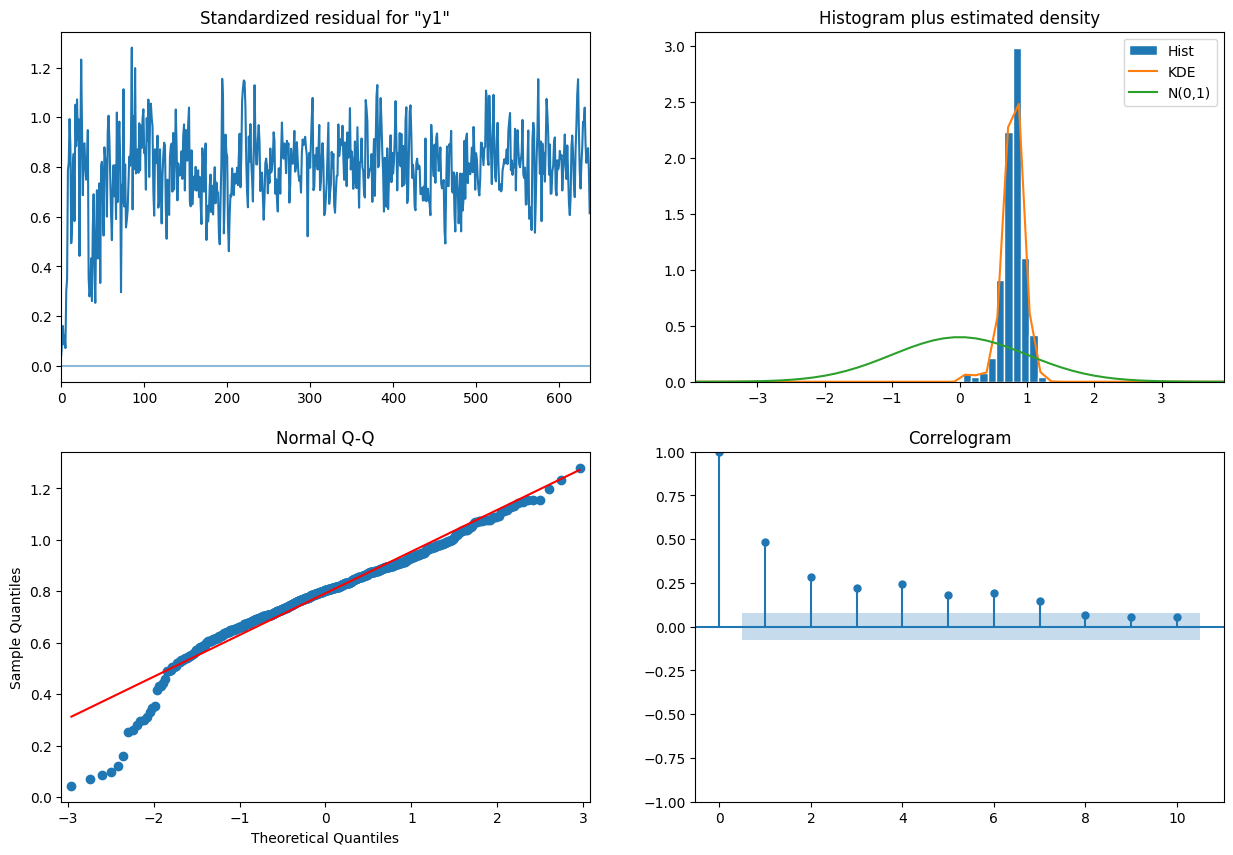

                        Exponential Smoothing Results                         
Dep. Variable:                      y   No. Observations:                  643
Model:                   ETS(A, N, N)   Log Likelihood                 547.531
Date:                Wed, 29 Jul 2026   AIC                          -1089.063
Time:                        17:07:44   BIC                          -1075.664
Sample:                             0   HQIC                         -1083.863
                                - 643   Scale                            0.011
Covariance Type:                  opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.039     25.318      0.000       0.922       1.077
initial_level       0.3801    258.403      0.001      0.999    -506.081     506.842
Ljung-Box (L1) (Q):             

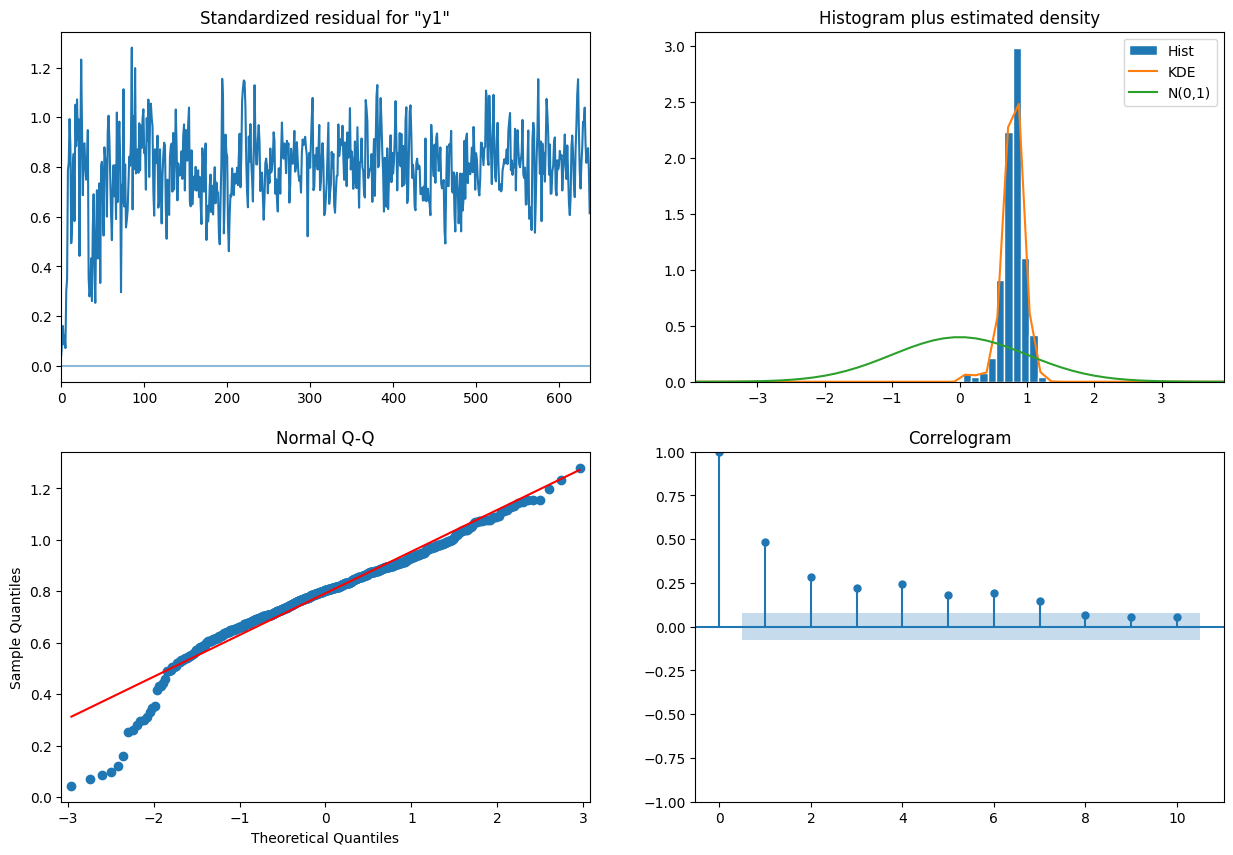

In [24]:
for var in [z, Thv, RH, u, v]:
    # Setup the model
    mod = sm.tsa.statespace.ExponentialSmoothing(var)

    # Fit it using MLE (recall that we are fitting the three variance parameters)
    res = mod.fit(disp=False)
    print(res.summary())
    fig=results.plot_diagnostics()
    fig.set_size_inches(15,10)
    plt.show(block=True)


c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                2435.320
                   + 1 factors in 1 blocks   AIC                          -4860.640
                     + AR(1) idiosyncratic   BIC                          -4838.309
Date:                     Wed, 29 Jul 2026   HQIC                         -4851.974
Time:                             17:07:44   EM Iterations                        3
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

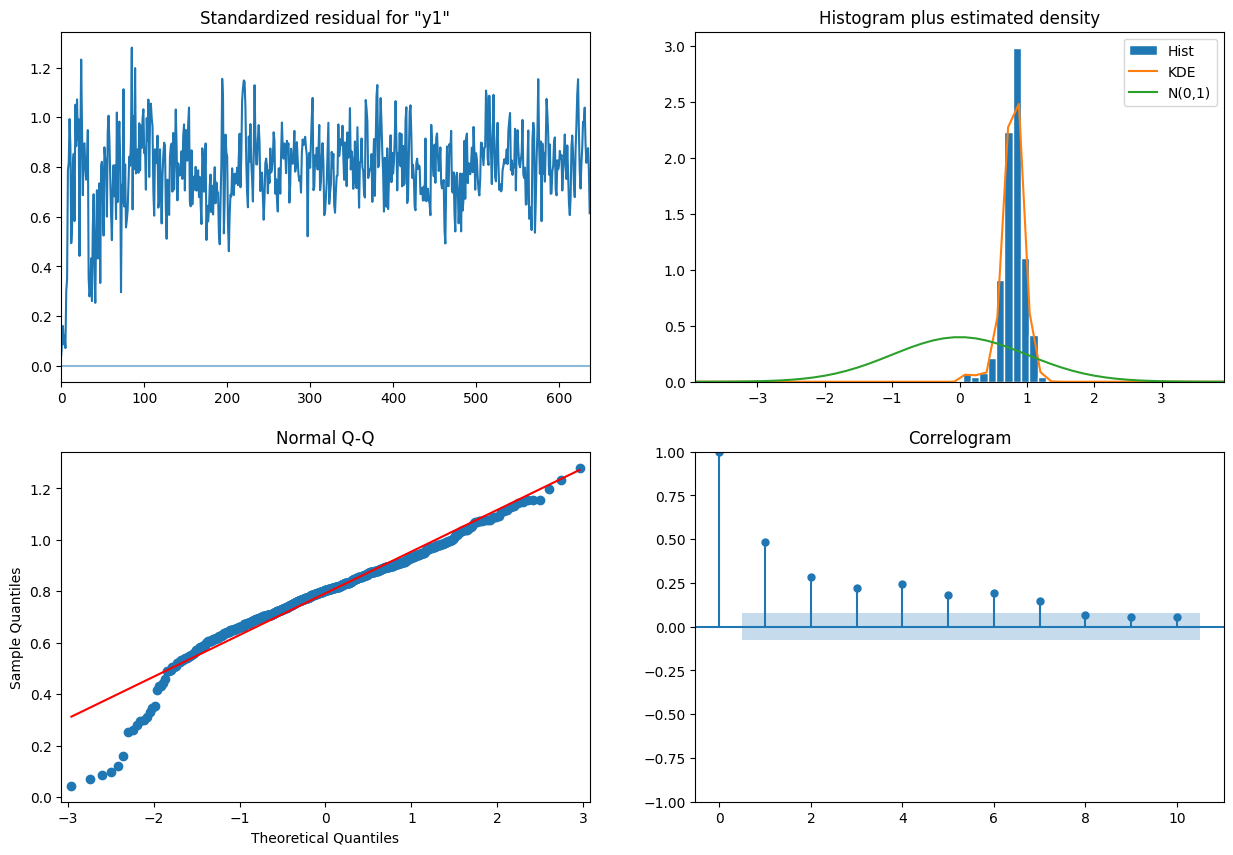

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                1752.556
                   + 1 factors in 1 blocks   AIC                          -3495.112
                     + AR(1) idiosyncratic   BIC                          -3472.781
Date:                     Wed, 29 Jul 2026   HQIC                         -3486.446
Time:                             17:07:45   EM Iterations                       18
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

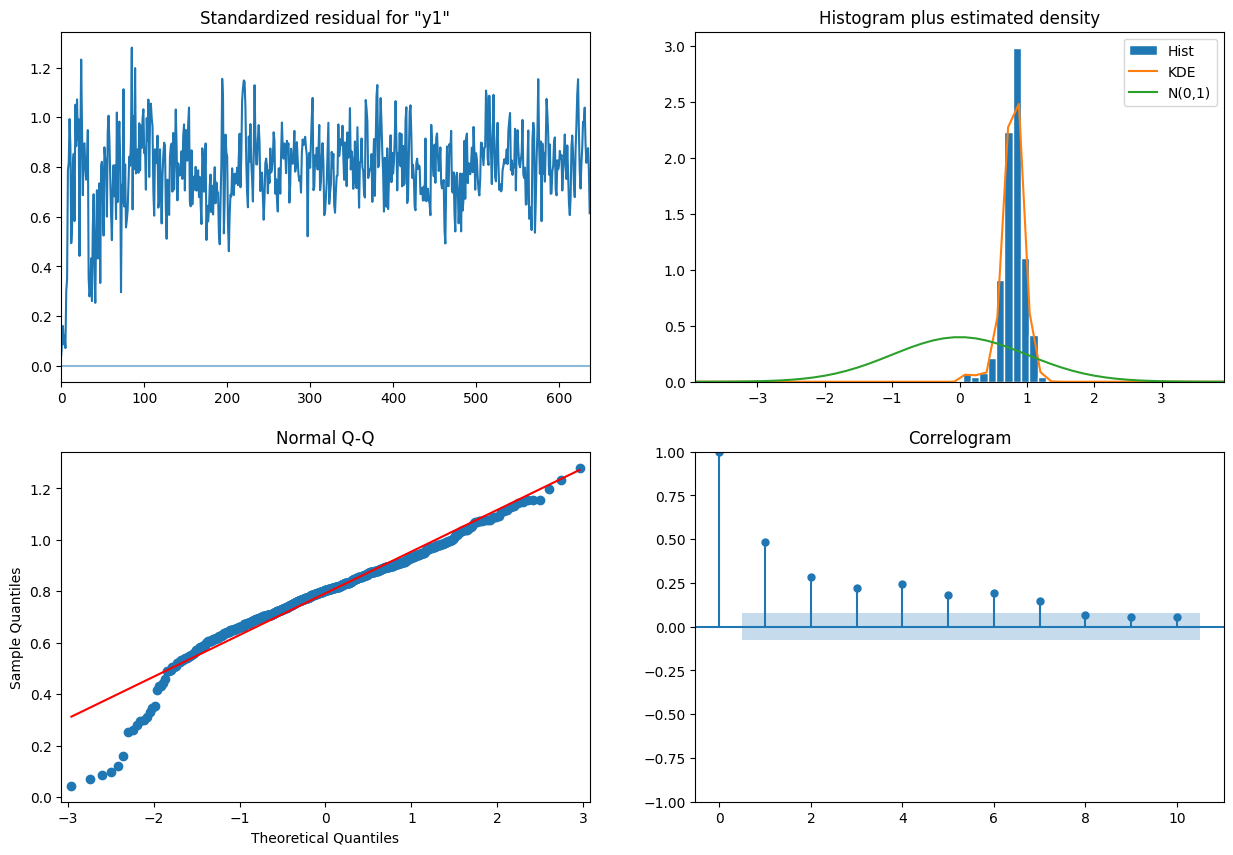

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                 702.837
                   + 1 factors in 1 blocks   AIC                          -1395.675
                     + AR(1) idiosyncratic   BIC                          -1373.344
Date:                     Wed, 29 Jul 2026   HQIC                         -1387.009
Time:                             17:07:46   EM Iterations                      338
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

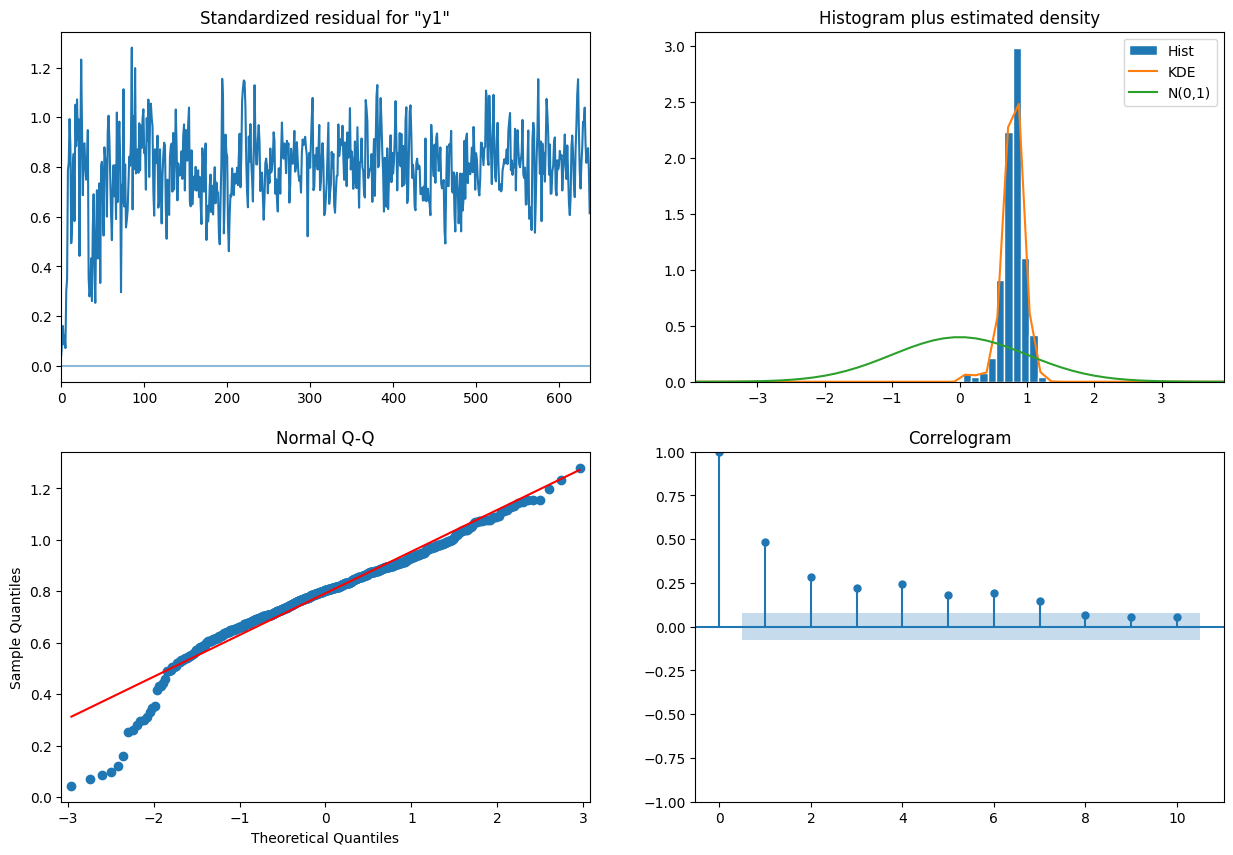

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                1479.498
                   + 1 factors in 1 blocks   AIC                          -2948.997
                     + AR(1) idiosyncratic   BIC                          -2926.666
Date:                     Wed, 29 Jul 2026   HQIC                         -2940.331
Time:                             17:07:46   EM Iterations                        4
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

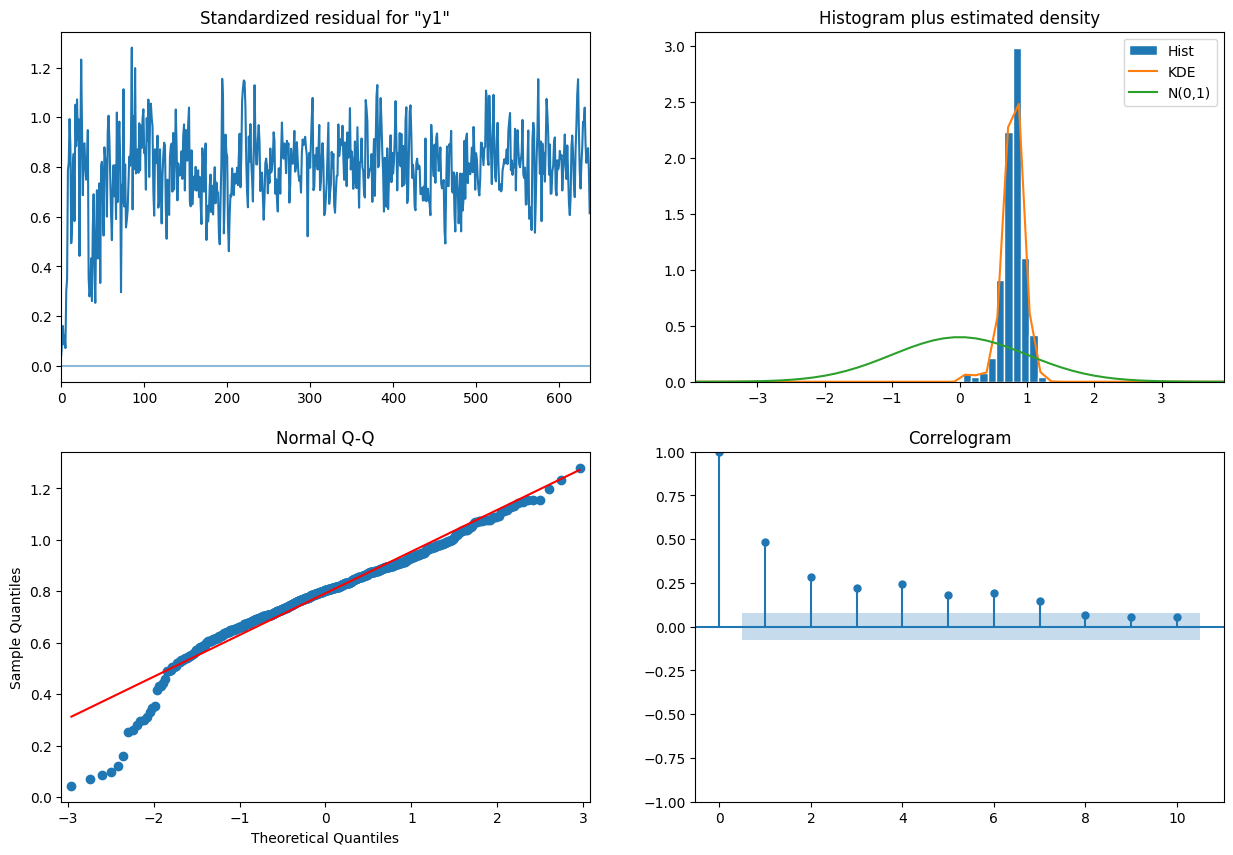

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['k_factors', 'factor_order']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                               Dynamic Factor Results                              
Dep. Variable:                           y   No. Observations:                  643
Model:                Dynamic Factor Model   Log Likelihood                 878.967
                   + 1 factors in 1 blocks   AIC                          -1747.934
                     + AR(1) idiosyncratic   BIC                          -1725.604
Date:                     Wed, 29 Jul 2026   HQIC                         -1739.268
Time:                             17:07:47   EM Iterations                       99
Sample:                                  0                                         
                                     - 643                                         
Covariance Type:              Not computed                                         
                    Observation equation:                     
Factor loadings:          0    idiosyncratic: AR(1)       var.
----------------------------------

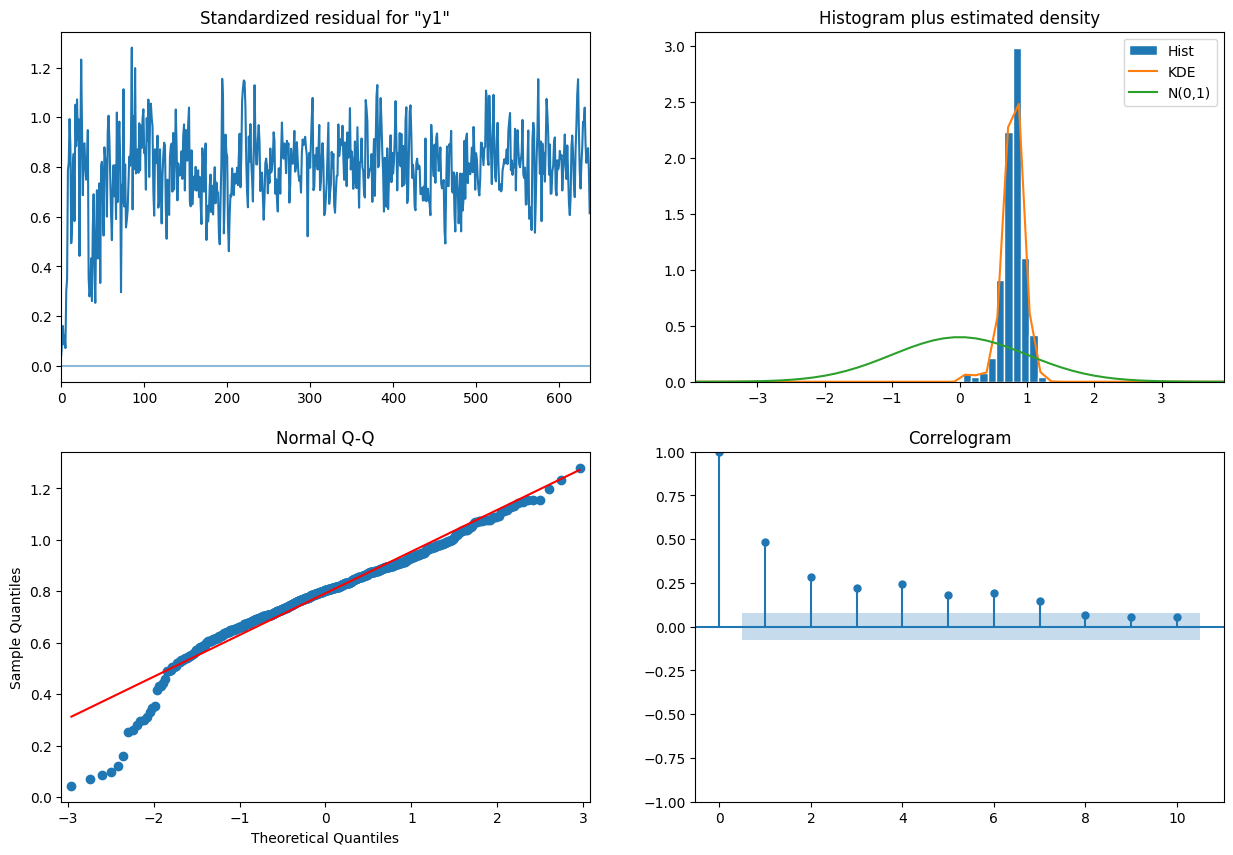

In [25]:
for var in [z, Thv, RH, u, v]:
    # Setup the model
    mod = sm.tsa.DynamicFactorMQ(var, k_factors=1, factor_order=2)

    # Fit it using MLE (recall that we are fitting the three variance parameters)
    res = mod.fit(disp=False)
    print(res.summary())
    fig=results.plot_diagnostics()
    fig.set_size_inches(15,10)
    plt.show(block=True)


In [36]:
endog[:100].shape

(100, 5)

c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:373: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\tomma\Documents\SDC\Repos\GRUAN_EDA\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                 Statespace Model Results                                 
Dep. Variable:     ['y1', 'y2', 'y3', 'y4', 'y5']   No. Observations:                  100
Model:                                 VARMA(2,2)   Log Likelihood               -2969.591
                                      + intercept   AIC                           6159.181
Date:                            Wed, 29 Jul 2026   BIC                           6445.750
Time:                                    17:39:25   HQIC                          6275.161
Sample:                                         0                                         
                                            - 100                                         
Covariance Type:                              opg                                         
Ljung-Box (L1) (Q):     58.88, 96.89, 89.26, 98.41, 98.11   Jarque-Bera (JB):    3.01, 13.28, 17.00, 5.09, 9.05
Prob(Q):                     0.00, 0.00, 0.00, 0.00, 0.00   Prob(JB):

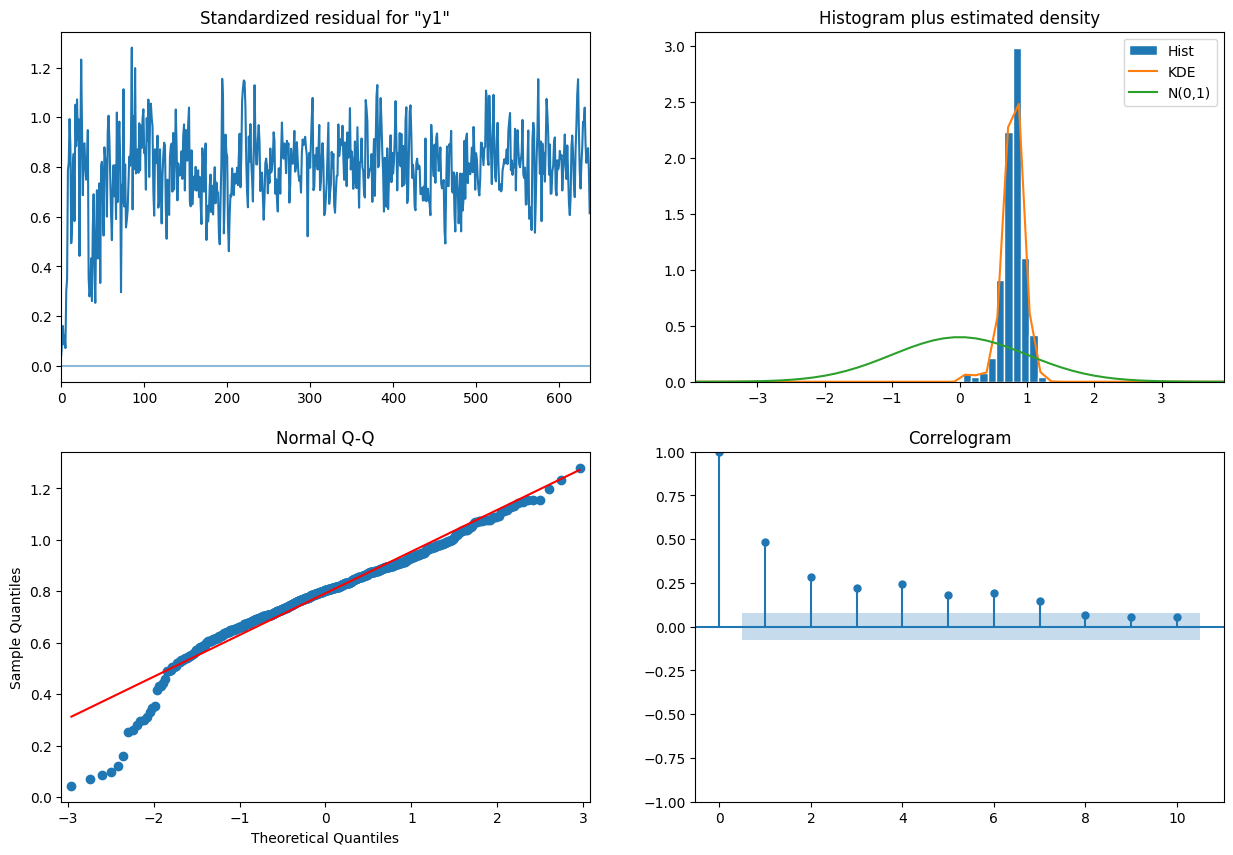

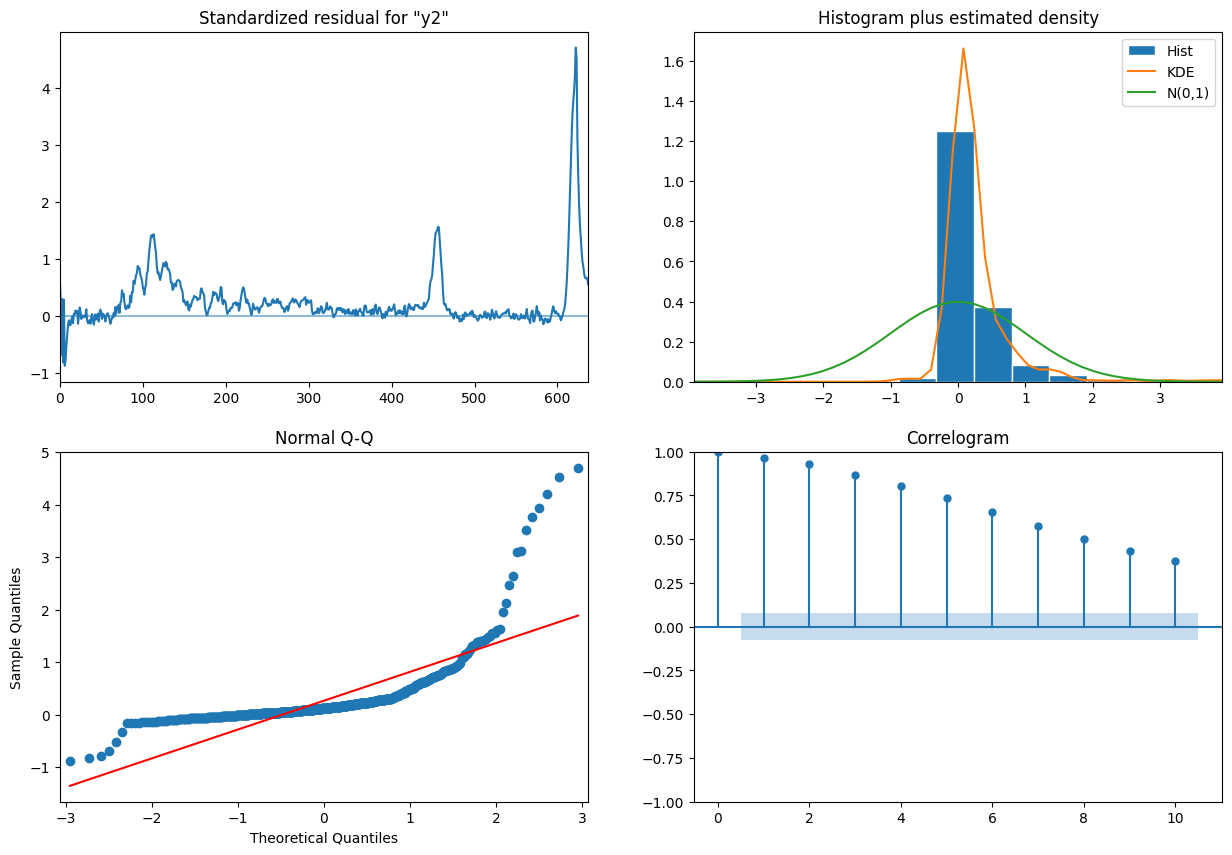

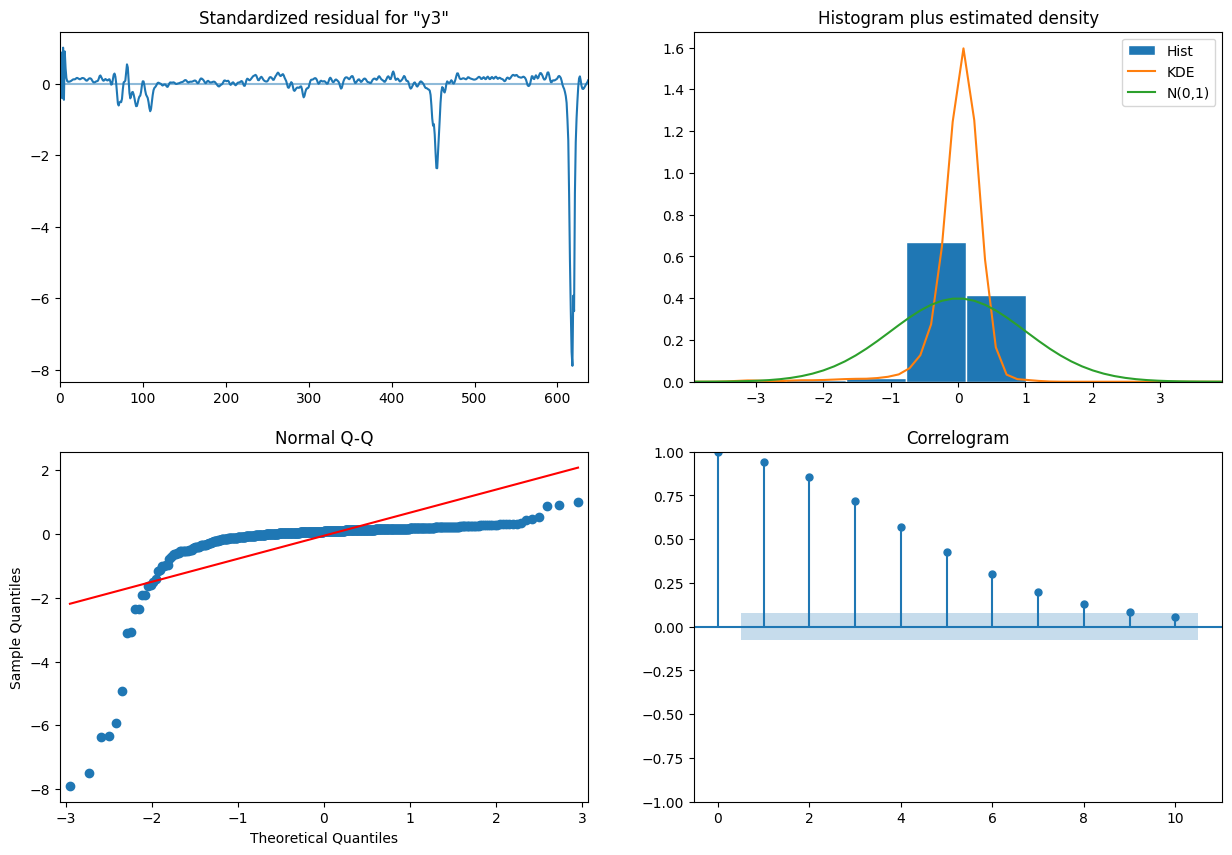

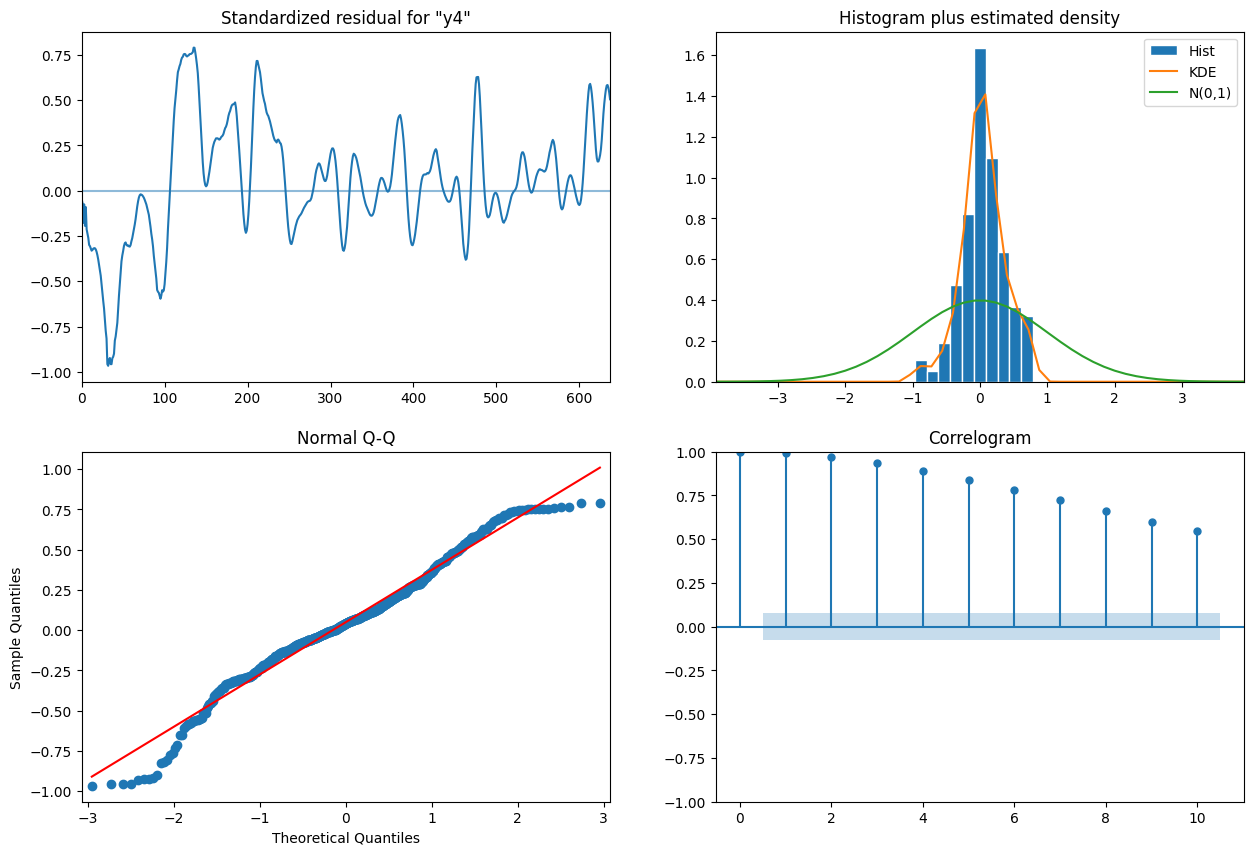

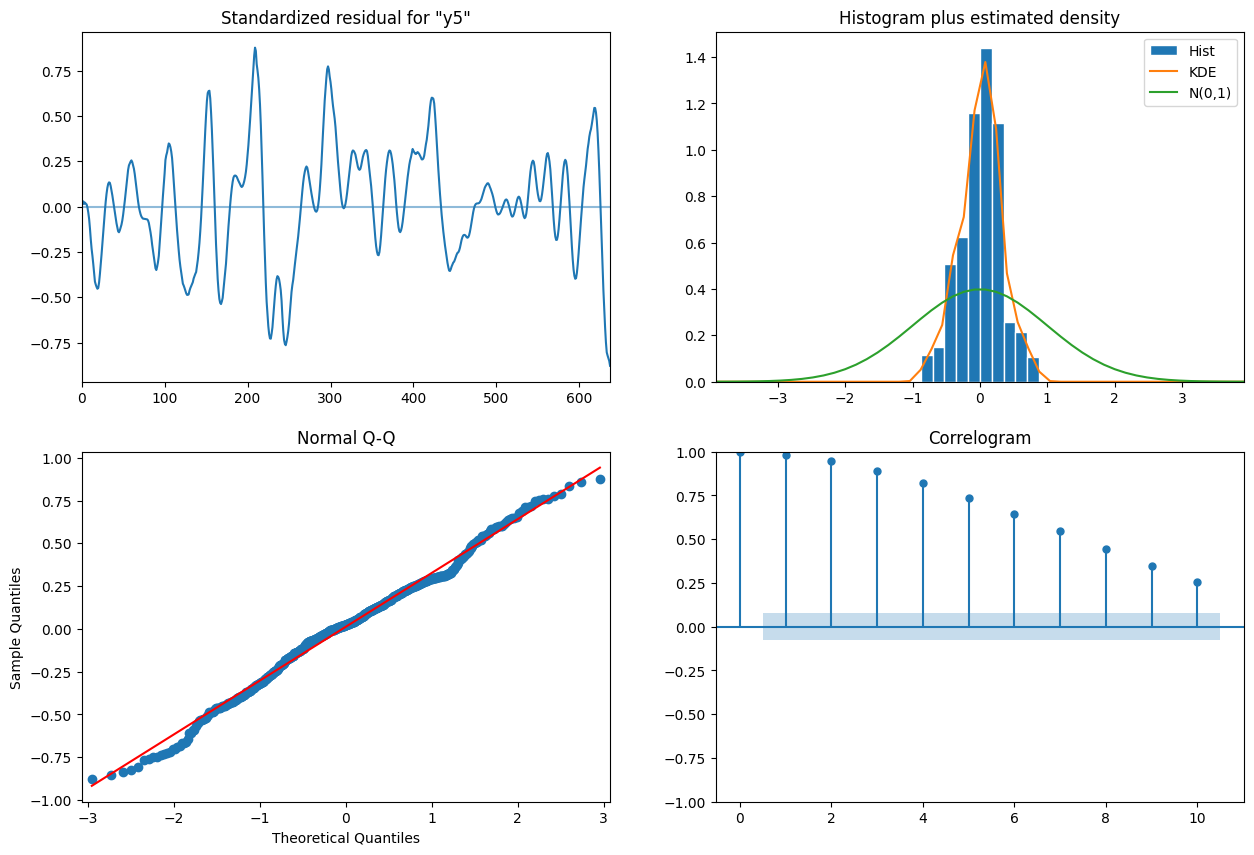

In [66]:
mod =sm.tsa.VARMAX(endog[:100], order=(2,2), error_cov_type='diagonal')

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
for i in range(5):
    fig=results.plot_diagnostics(i)
    fig.set_size_inches(15,10)
    plt.show(block=True)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1032.076
Date:                Wed, 29 Jul 2026   AIC                           2072.151
Time:                        17:28:05   BIC                           2090.010
Sample:                             0   HQIC                          2079.082
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.5437      0.127      4.280      0.000       0.295       0.793
ar.L1          0.8995      0.024     37.397      0.000       0.852       0.947
ma.L1         -0.7016      0.040    -17.346      0.0

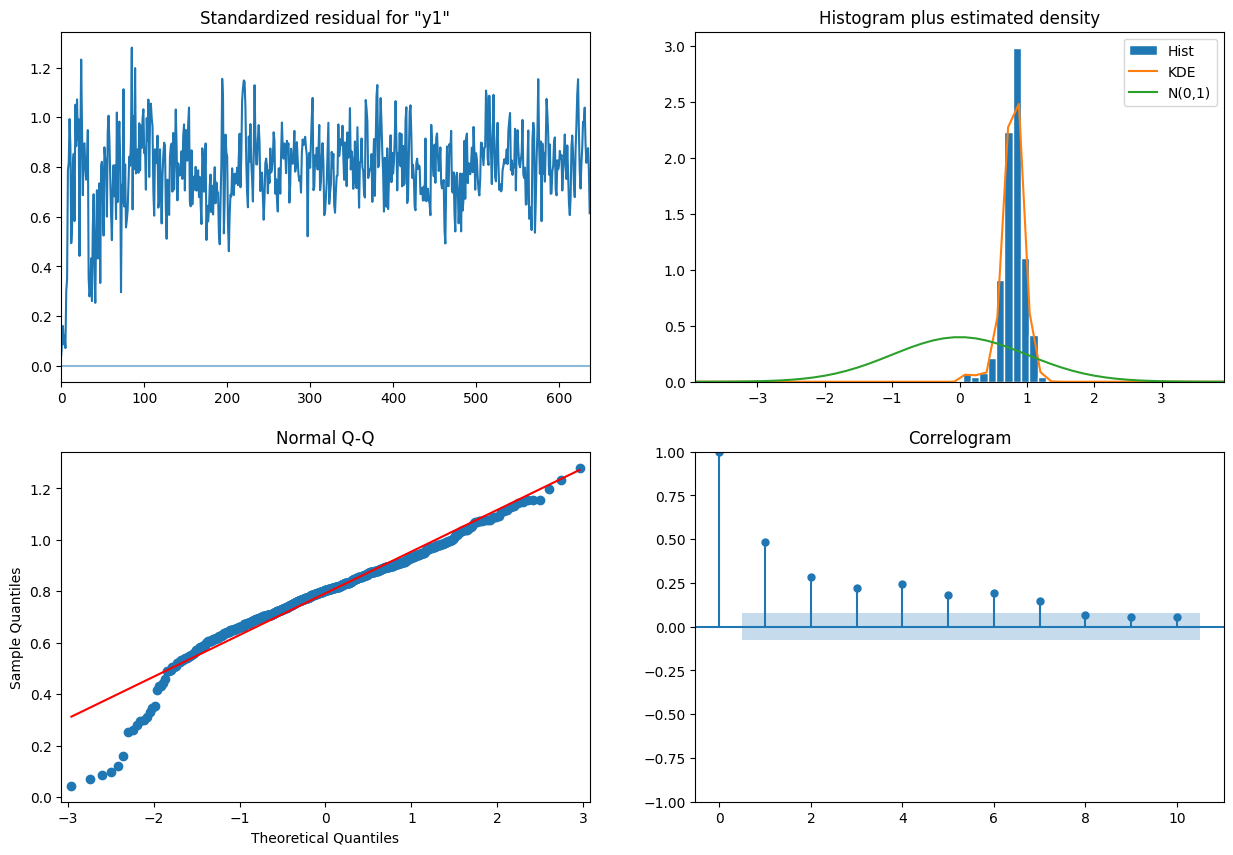

In [59]:
mod = sm.tsa.statespace.SARIMAX(z, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                1194.945
Date:                Wed, 29 Jul 2026   AIC                          -2381.890
Time:                        17:27:54   BIC                          -2364.031
Sample:                             0   HQIC                         -2374.959
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0017      0.001      1.786      0.074      -0.000       0.004
ar.L1          0.9502      0.008    119.789      0.000       0.935       0.966
ma.L1         -0.4534      0.013    -34.812      0.0

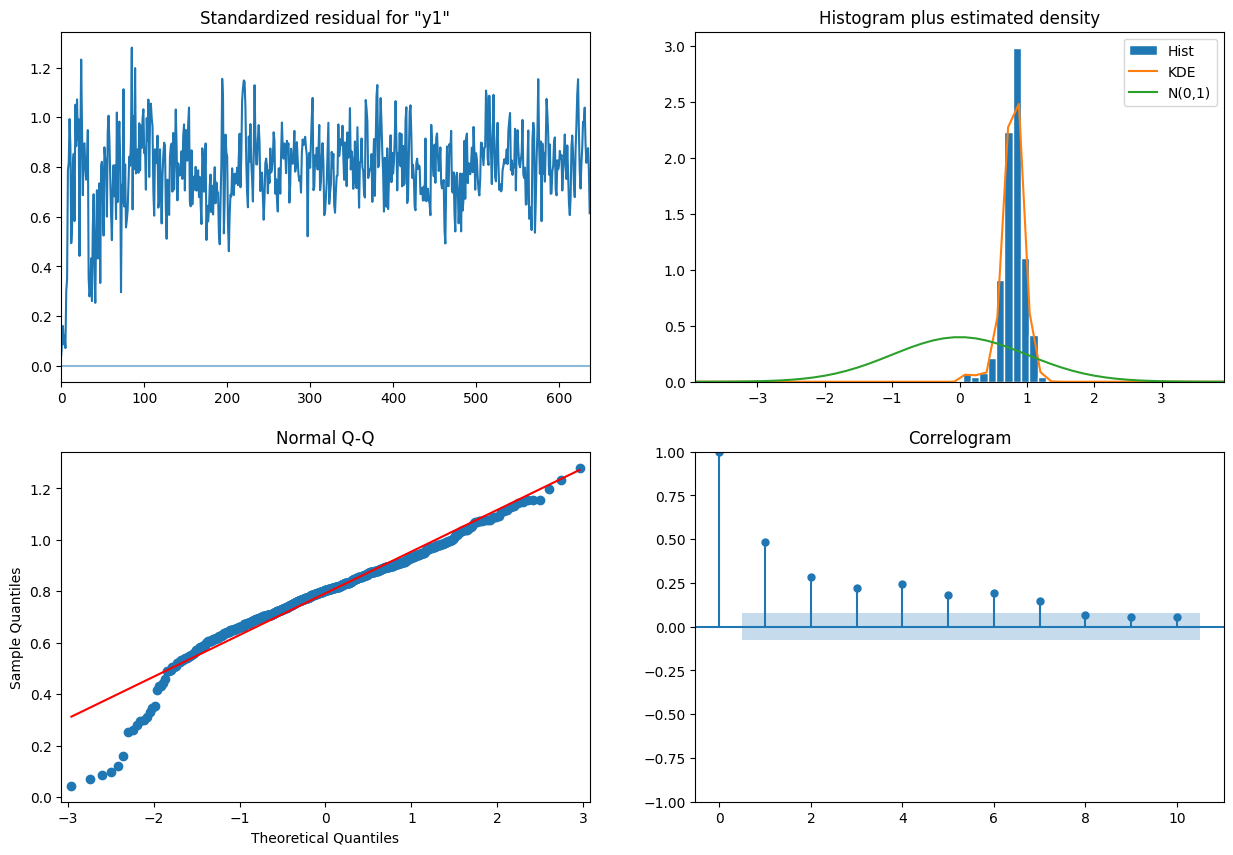

In [58]:
mod = sm.tsa.statespace.SARIMAX(Thv, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -566.693
Date:                Wed, 29 Jul 2026   AIC                           1141.387
Time:                        17:27:41   BIC                           1159.245
Sample:                             0   HQIC                          1148.317
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0120      0.029     -0.413      0.680      -0.069       0.045
ar.L1          0.8920      0.006    152.503      0.000       0.881       0.903
ma.L1          0.0035      0.009      0.412      0.6

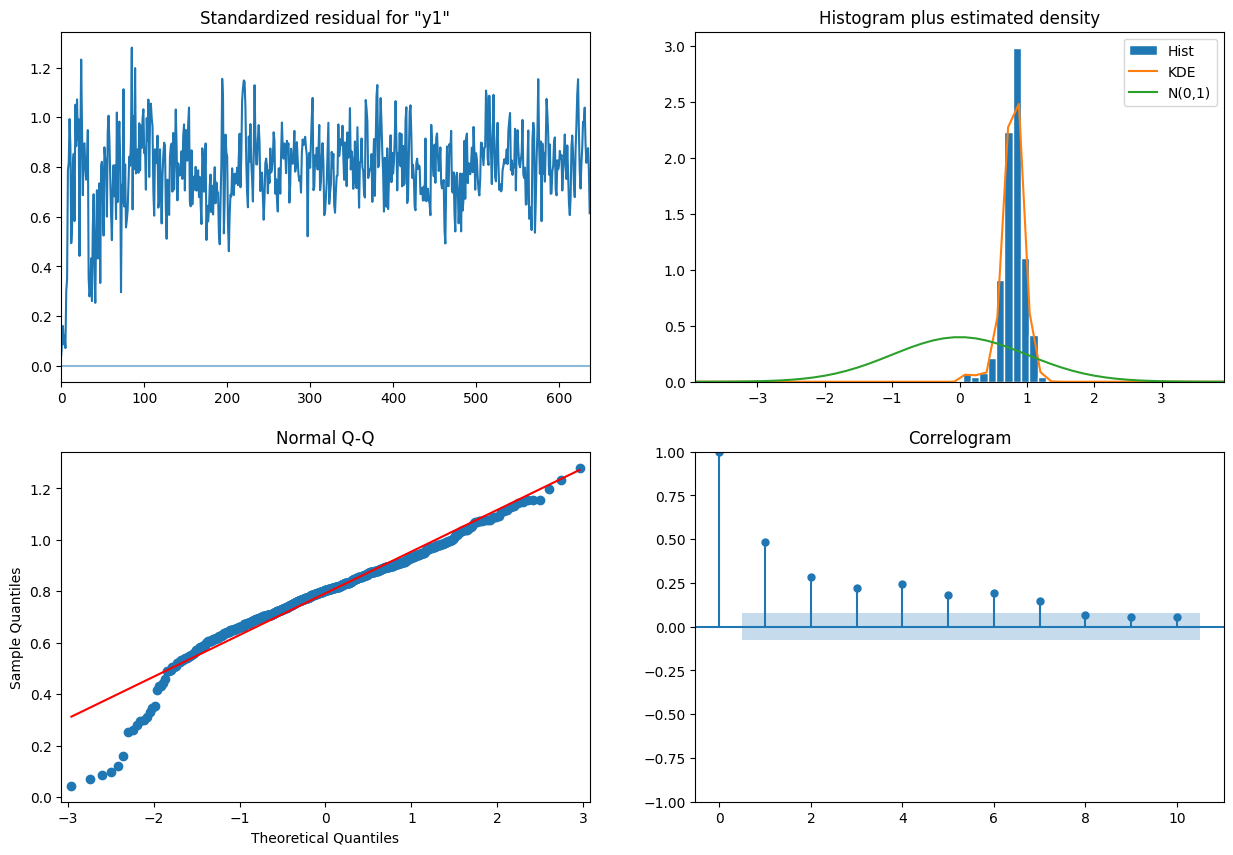

In [57]:
mod = sm.tsa.statespace.SARIMAX(RH, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 860.250
Date:                Wed, 29 Jul 2026   AIC                          -1712.499
Time:                        17:28:33   BIC                          -1694.641
Sample:                             0   HQIC                         -1705.568
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0007      0.002      0.389      0.697      -0.003       0.004
ar.L1          0.9570      0.015     62.395      0.000       0.927       0.987
ma.L1         -0.4475      0.025    -17.869      0.0

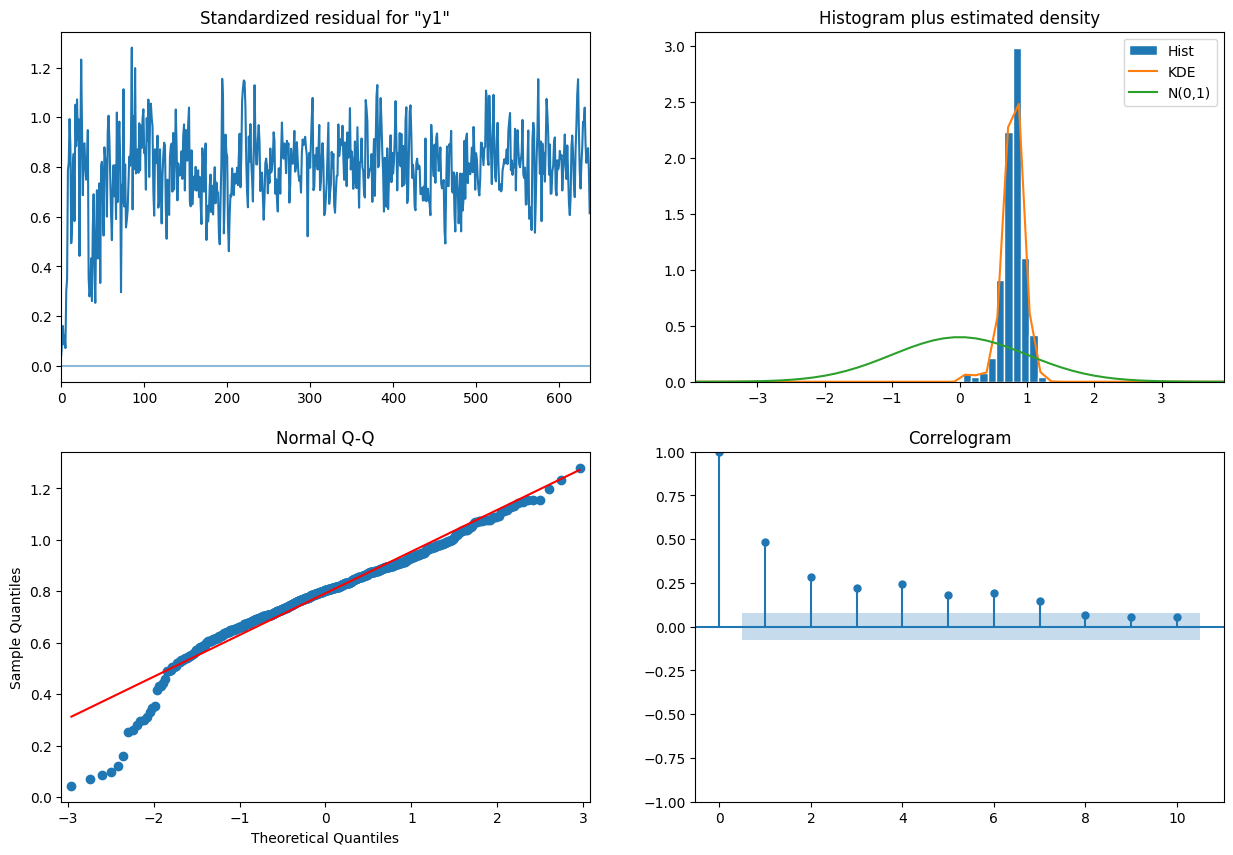

In [62]:
mod = sm.tsa.statespace.SARIMAX(u, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  643
Model:               SARIMAX(1, 1, 1)   Log Likelihood                1706.633
Date:                Wed, 29 Jul 2026   AIC                          -3405.265
Time:                        17:28:38   BIC                          -3387.407
Sample:                             0   HQIC                         -3398.335
                                - 643                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0001      0.001     -0.111      0.912      -0.002       0.002
ar.L1          0.9693      0.011     90.245      0.000       0.948       0.990
ma.L1          0.5031      0.016     31.808      0.0

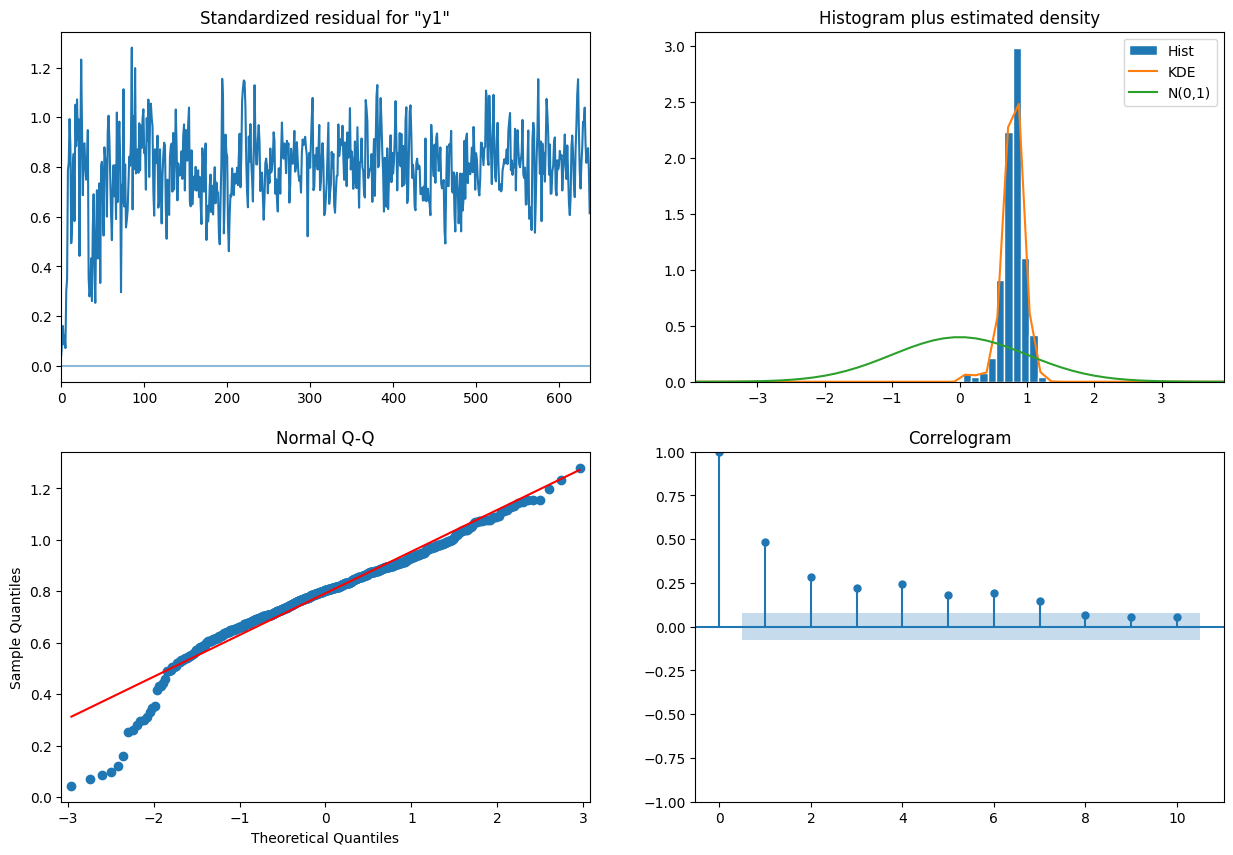

In [63]:
mod = sm.tsa.statespace.SARIMAX(v, trend='c', order=(1,1,1))

# Fit it using MLE (recall that we are fitting the three variance parameters)
res = mod.fit(disp=False)
print(res.summary())
fig=results.plot_diagnostics()
fig.set_size_inches(15,10)
plt.show(block=True)